# 04 — Maestro full-dataset pedal style comparison

All 2552 MIDI files in the MAESTRO v3 dataset were scanned with a 30-second
sliding window.  For each pedal-label type the window with the highest fraction
of that label was identified.  The three pieces below were chosen as the clearest
representatives of three distinct style clusters.  A supplementary section shows
the best examples for all five label types.

| Piece | Composer | Dominant pedal style | Purity in best window |
|-------|----------|---------------------|----------------------|
| Sonata in D Major, D850 | Schubert | Rhythmic *Wechselpedal*: brief, on-beat, full depth | 100% (22/22 events) |
| Sonata No. 2, Op. 35 | Chopin | Anticipatory legato: pedal before note onset | 100% (10/10 events) |
| Etude-Tableaux Op. 39 No. 8 | Rachmaninoff | Extended sustain: long full-depth pedals | 100% (12/12 events) |

**Goal:** show that binary on/off and simple depth-threshold analysis cannot
distinguish these three musically distinct pedaling styles — but the three-layer
encoding can.  See `scripts/maestro_full_scan.py` for the scanning methodology.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pretty_midi
import warnings
warnings.filterwarnings('ignore')
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import Optional
from pathlib import Path

from layers import extract_pedal_events

In [2]:
MAESTRO = '/Volumes/Extreme SSD/maestro-v3.0.0'

# Three pieces chosen by scanning all 2552 Maestro MIDI files and maximising
# label purity in the best 30-second window.  Each represents a distinct
# pedaling style cluster.  See scripts/maestro_full_scan.py.
#
#  Rhythmic   → Schubert D850           100% rhythmic,  22 events in 30s
#  Anticipatory→ Chopin Sonata No. 2    100% anticipatory, 10 events
#  Extended   → Rachmaninoff Op.39 No.8 100% extended,  12 events
PIECES = [
    dict(
        name='Schubert, Sonata in D Major, D850',
        short='Schubert',
        midi=f'{MAESTRO}/2004/MIDI-Unprocessed_XP_15_R2_2004_01_ORIG_MID--AUDIO_15_R2_2004_01_Track01_wav.midi',
        T0=145.0, T1=175.0,
        color='#546E7A',
        expected='rhythmic Wechselpedal',
    ),
    dict(
        name='Chopin, Sonata No. 2 in B-flat Minor, Op. 35',
        short='Chopin',
        midi=f'{MAESTRO}/2013/ORIG-MIDI_02_7_10_13_Group_MID--AUDIO_14_R3_2013_wav--2.midi',
        T0=830.0, T1=860.0,
        color='#B71C1C',
        expected='anticipatory legato',
    ),
    dict(
        name='Rachmaninoff, Etude-Tableaux Op. 39 No. 8 in D Minor',
        short='Rachmaninoff',
        midi=f'{MAESTRO}/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi',
        T0=85.0, T1=115.0,
        color='#1565C0',
        expected='extended sustain',
    ),
]

# Five label types + their colours
LABEL_COLORS = {
    'rhythmic':     '#4CAF50',
    'anticipatory': '#FF9800',
    'extended':     '#2196F3',
    'half-pedal':   '#9C27B0',
    'touch':        '#00BCD4',
    'note-blend':   '#F44336',
    'other':        '#90A4AE',
}

## Category computation: framework, implementation, and MAESTRO adaptation

### 1 · What the paper defines

Zhang et al. (MEC 2026) propose a three-layer framework:

| Layer | Name | What it stores |
|-------|------|----------------|
| I | Physical | Raw CC64 trajectory: `(t_onset, t_offset, d(t))` |
| II | Contextual | Score-aligned descriptors (δ_onset, δ_offset, AR) |
| III | Semantic | Interpretable intent labels derived from Layer II |

**Layer II descriptors** (require score alignment):

$$\delta_{onset} = \frac{t_{onset} - t_{grid}}{IBI}, \qquad \delta_{offset} = \frac{t_{offset} - t_{grid}}{IBI}$$

where *t_grid* is the nearest metric beat and *IBI* is the local inter-beat interval.
The *articulation ratio* per note *n* in voice *v* is:

$$AR(n) = \frac{d_{eff}(n)}{IOI(n, n+1)}$$

where *d_eff* is the effective sounding duration (extended to pedal offset if the pedal holds the note longer than its written duration).

**Layer III labels — paper's illustrative examples (Section 3.3):**

| Label | Condition | Musical meaning |
|-------|-----------|----------------|
| rhythmic pedaling | δ_onset ≥ 0, **δ_offset < 0**, AR ≤ 1 | On-beat, released before next beat; classical Wechselpedal |
| coloring / impressionist | \|δ_onset\| > 0, \|δ_offset\| > 0, max d(t) **≈ 0.5** | Asymmetric timing, partial depth; coloristic resonance |
| anticipatory (big volume) | **δ_onset < 0**, δ_offset > 0, d(t) ≈ 1 | Pressed before beat, released after; legato across barlines |

> The paper presents these as *examples of what labels can look like*, not an exhaustive list. The framework is intentionally open-ended; new labels can be added for other stylistic phenomena.

---

### 2 · `src/layers.py` — score-aligned implementation (Mozart-calibrated)

This module implements the full framework for datasets with score alignment
(currently: Batik-plays-Mozart). It extends the paper's three examples with
three additional labels, and sets thresholds empirically from the Mozart corpus
(n = 10,245 events).

| Label | Condition (IBI-normalised) | Paper anchor | Threshold origin |
|-------|---------------------------|--------------|-----------------|
| `half-pedal` | max_d < **0.50** | depth ≈ 0.5 from "coloring" | 0.50 is well below corpus median (>75% reach full depth) |
| `touch` | dur_ibi < **0.30**, max_d ≥ 0.50 | *extension* | p10 of dur_ibi distribution |
| `anticipatory` | δ_onset < **−0.10**, max_d ≥ 0.50, dur_ibi ≥ 0.30 | δ_onset < 0 from paper | p25 of δ_onset distribution |
| `extended` | dur_ibi > **1.07**, max_d ≥ 0.50 | *extension* | p75 of dur_ibi distribution |
| `rhythmic` | δ_onset ≥ −0.10, **δ_offset < 0.05**, 0.30 ≤ dur_ibi ≤ 1.07 | δ_onset ≥ 0, δ_offset < 0 from paper | relaxed to p25 boundary on onset side |
| `note-blend` | AR_median > **2.68**, max_d ≥ 0.50, dur_ibi ≥ 0.30 | AR ≤ 1 in "rhythmic" motivates the AR axis | p75 of AR distribution |
| `other` | none of the above | — | — |

**Faithfulness to the paper:**
- `rhythmic`: faithful. δ_onset threshold relaxed slightly (0 → −0.10 IBI) to absorb near-zero timing jitter; δ_offset condition preserved.
- `anticipatory`: faithful. Threshold (−0.10) is corpus p25 rather than the paper's qualitative δ_onset < 0; the paper's δ_offset > 0 condition is **dropped** (requires pedal held past next beat — this is captured instead by the `extended` label).
- `half-pedal`: partially faithful. Captures the depth ≈ 0.5 criterion from "coloring"; the paper's timing conditions (|δ_onset| > 0, |δ_offset| > 0) are **dropped** to keep the label useful as a depth-only filter.
- `touch`, `extended`, `note-blend`: **extensions** — not defined in the paper, added to cover phenomena visible in the Mozart corpus.

---

### 3 · MAESTRO adaptation v2 — beat-aligned (current implementation)

`pretty_midi.get_beats()` extracts beat times from the MIDI tempo map.
This fixes all deviations that required the beat grid.  AR remains approximate.

| Descriptor | v1 (note-lag proxy) | v2 (beat-aligned) | Status |
|------------|--------------------|--------------------|--------|
| δ_onset | lag to nearest note onset (s) | `(t_onset − t_beat) / IBI` | ✅ Fixed |
| δ_offset | not computed | `(t_offset − t_beat) / IBI` | ✅ Fixed |
| dur_ibi | absolute seconds | `dur / IBI` (tempo-normalised) | ✅ Fixed |
| AR | not computed | voice-agnostic IOI proxy | ⚠ Approximate |

**What is now correct:**
- `rhythmic` checks both δ_onset ≥ −0.10 *and* δ_offset < 0.05 (paper's δ_offset < 0 condition restored)
- `anticipatory` threshold is −0.10 IBI (corpus p25), not an ad-hoc −70 ms
- `extended` threshold is 1.07 IBI (corpus p75), not a fixed 1.20 s
- `note-blend` is re-enabled using the voice-agnostic AR proxy

**Remaining limitation — AR approximation:**
The paper defines AR per voice with score-level IOI (next note onset *in the same voice*).
The proxy here uses any-pitch IOI (nearest following note onset of any pitch).
In dense homophonic textures this is a reasonable approximation; in polyphonic
music with overlapping voices it can over- or under-estimate AR.
`note-blend` labels from this proxy should be treated as indicative, not definitive.

In [ ]:
@dataclass
class MaestroEvent:
    onset_sec:   float
    offset_sec:  float
    times:       np.ndarray
    depths:      np.ndarray
    # Note-lag proxy (kept for backward compat in plots)
    lag_sec:     Optional[float] = None
    dur_sec:     Optional[float] = None
    max_depth:   Optional[float] = None
    # Beat-aligned IBI-normalised Layer II descriptors
    delta_onset:  Optional[float] = None
    delta_offset: Optional[float] = None
    dur_ibi:      Optional[float] = None
    ar_approx:    Optional[float] = None   # voice-agnostic AR proxy
    labels:       list = field(default_factory=list)


def load_midi_piece(midi_path):
    pm = pretty_midi.PrettyMIDI(midi_path)
    controls = sorted(
        [{'number': 64, 'time': cc.time, 'value': cc.value}
         for inst in pm.instruments
         for cc in inst.control_changes if cc.number == 64],
        key=lambda c: c['time']
    )
    note_ons = np.array(sorted(
        n.start for inst in pm.instruments
        if not inst.is_drum for n in inst.notes
    ))
    return controls, note_ons, pm.get_end_time(), pm


def _beat_ibi(beats, t):
    """Nearest beat time and local IBI for time t."""
    idx = int(np.argmin(np.abs(beats - t)))
    lo, hi = max(0, idx - 1), min(len(beats) - 1, idx + 1)
    ibi = (beats[hi] - beats[lo]) / max(hi - lo, 1)
    return beats[idx], max(ibi, 1e-4)


def layer2_maestro(events, note_ons, pm):
    """
    Layer II: IBI-normalised δ_onset, δ_offset, dur_ibi via pm.get_beats().
    Note-lag proxy stored in lag_sec for backward-compat scatter plots.
    Voice-agnostic AR approximation stored in ar_approx.
    """
    beats = pm.get_beats()

    all_notes = sorted(
        [(n.start, n.end)
         for inst in pm.instruments if not inst.is_drum
         for n in inst.notes],
        key=lambda x: x[0]
    )
    n_on  = np.array([x[0] for x in all_notes])
    n_off = np.array([x[1] for x in all_notes])

    for ev in events:
        idx_n = int(np.argmin(np.abs(note_ons - ev.onset_sec)))
        ev.lag_sec   = ev.onset_sec - note_ons[idx_n]
        ev.dur_sec   = ev.offset_sec - ev.onset_sec
        ev.max_depth = float(np.max(ev.depths)) if len(ev.depths) else 0.0

        t_on,  ibi_on  = _beat_ibi(beats, ev.onset_sec)
        t_off, ibi_off = _beat_ibi(beats, ev.offset_sec)
        ev.delta_onset  = (ev.onset_sec  - t_on)  / ibi_on
        ev.delta_offset = (ev.offset_sec - t_off) / ibi_off
        ev.dur_ibi      = ev.dur_sec / ibi_on

        mask = (n_on >= ev.onset_sec) & (n_on < ev.offset_sec)
        idxs = np.where(mask)[0]
        ars = []
        for i in idxs:
            if i + 1 >= len(n_on):
                continue
            ioi = n_on[i + 1] - n_on[i]
            if ioi < 1e-3:
                continue
            d_eff = max(n_off[i], ev.offset_sec) - n_on[i]
            ars.append(d_eff / ioi)
        ev.ar_approx = float(np.median(ars)) if ars else None


# Single source of truth — import from src/layers.py
from layers import (
    _DEPTH_HALF,
    _DON_ANTICIPATE,
    _DUR_TOUCH     as _DUR_TOUCH_IBI,
    _DUR_SUSTAIN,
    _AR_CORPUS_P75 as _AR_BLEND,
)
_DOFF_RHYTHMIC = 0.05   # δ_offset < 0.05 IBI — not a named constant in layers.py


def layer3_maestro(events):
    """IBI-normalised Layer III labels — same rules as src/layers.py."""
    for ev in events:
        if ev.max_depth is None or ev.delta_onset is None:
            continue
        labels = []
        d     = ev.max_depth
        d_on  = ev.delta_onset
        d_off = ev.delta_offset
        dur   = ev.dur_ibi
        ar    = ev.ar_approx if ev.ar_approx is not None else 1.0

        if d < _DEPTH_HALF:
            labels.append('half-pedal')
        if dur < _DUR_TOUCH_IBI and d >= _DEPTH_HALF:
            labels.append('touch')
        if d_on < _DON_ANTICIPATE and d >= _DEPTH_HALF and dur >= _DUR_TOUCH_IBI:
            labels.append('anticipatory')
        if dur > _DUR_SUSTAIN and d >= _DEPTH_HALF:
            labels.append('extended')
        if (d_on >= _DON_ANTICIPATE and d_off < _DOFF_RHYTHMIC
                and _DUR_TOUCH_IBI <= dur <= _DUR_SUSTAIN and d >= _DEPTH_HALF):
            labels.append('rhythmic')
        if ar > _AR_BLEND and d >= _DEPTH_HALF and dur >= _DUR_TOUCH_IBI:
            labels.append('note-blend')

        ev.labels = labels if labels else ['other']

In [4]:
# Run all three analyses (~10 s total)
results = {p['short']: analyze_piece(p) for p in PIECES}

print(f'{"Piece":<12} {"Events":>7} {"dur_mean":>9} {"dur_p75":>8}'
      f' {"half_pct":>9} {"anticipatory_pct":>17}')
print('-' * 68)
for short, r in results.items():
    evs = r['events']
    durs   = [e.dur_sec   for e in evs]
    depths = [e.max_depth for e in evs]
    lags   = [e.lag_sec   for e in evs]
    half_pct = 100 * np.mean(np.array(depths) < _DEPTH_HALF)
    anti_pct = 100 * np.mean(np.array(lags)   < _LAG_ANTICIPATE)
    print(f'{short:<12} {len(evs):>7} {np.mean(durs):>9.2f}s'
          f' {np.percentile(durs,75):>8.2f}s {half_pct:>8.1f}% {anti_pct:>16.1f}%')

Piece         Events  dur_mean  dur_p75  half_pct  anticipatory_pct
--------------------------------------------------------------------
Schubert         156      0.79s     0.66s      2.6%              3.2%
Chopin           843      1.15s     1.38s      0.8%             11.4%
Rachmaninoff      83      2.11s     3.04s      6.0%              6.0%


## The case against binary on/off encoding

Binary on/off treats a CC64 value >= 10 as pedal-on (1) and anything below as
pedal-off (0).  The three panels below show the raw binarised signal for the
same 18-second excerpt from each piece.  The patterns look qualitatively similar --
a series of on/off pulses -- but the audio sounds completely different.
Listen to all three excerpts in the **Aligned views** section to hear why.

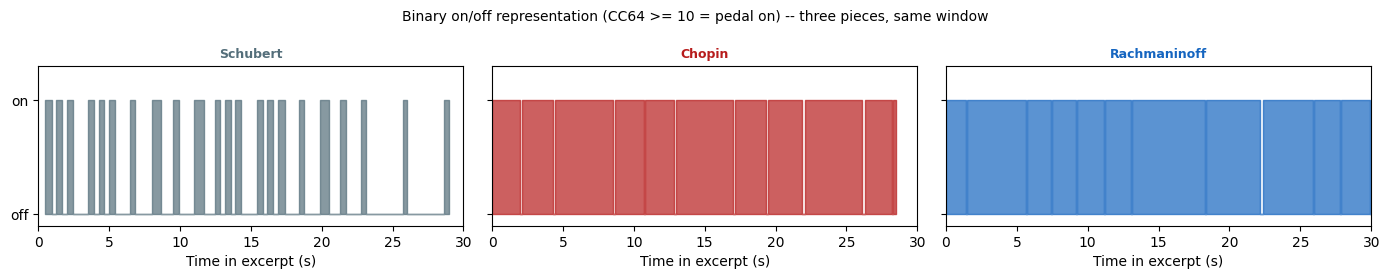

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 2.8), sharey=True)
fig.suptitle('Binary on/off representation (CC64 >= 10 = pedal on) -- three pieces, same window',
             fontsize=10)

for ax, p in zip(axes, PIECES):
    r = results[p['short']]
    mask = (r['t_raw'] >= p['T0']) & (r['t_raw'] <= p['T1'])
    t = r['t_raw'][mask] - p['T0']
    binary = (r['v_raw'][mask] * 127 >= 10).astype(float)
    ax.fill_between(t, 0, binary, step='post', color=p['color'], alpha=0.70)
    ax.set_xlim(0, p['T1'] - p['T0'])
    ax.set_ylim(-0.1, 1.3)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['off', 'on'])
    ax.set_xlabel('Time in excerpt (s)')
    ax.set_title(p['short'], fontsize=9, color=p['color'], fontweight='bold')

plt.tight_layout()
plt.show()

## Layer I -- raw CC64 depth

Layer I records the continuous depth trajectory, not just on/off.
Already at this level we can see that **Debussy** occasionally uses partial depth
(CC64 < 64, depth < 0.50) while Beethoven and Chopin stay near full pedal.

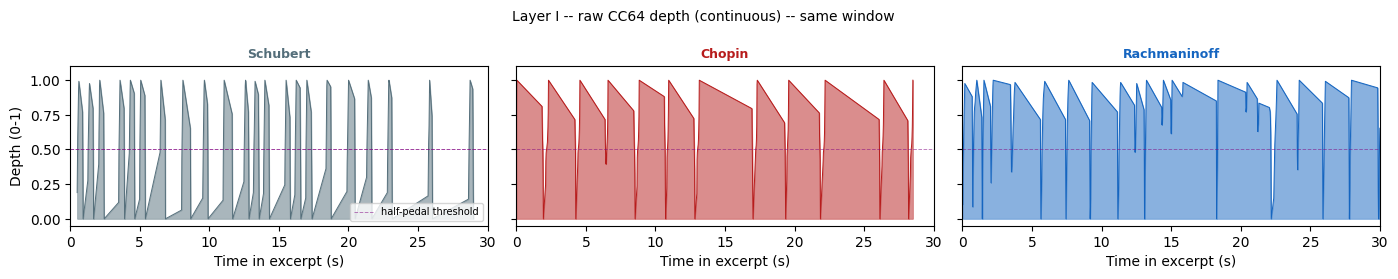

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 2.8), sharey=True)
fig.suptitle('Layer I -- raw CC64 depth (continuous) -- same window', fontsize=10)

for ax, p in zip(axes, PIECES):
    r = results[p['short']]
    mask = (r['t_raw'] >= p['T0']) & (r['t_raw'] <= p['T1'])
    t = r['t_raw'][mask] - p['T0']
    ax.fill_between(t, 0, r['v_raw'][mask], lw=0.6, color=p['color'], alpha=0.50)
    ax.plot(t, r['v_raw'][mask], lw=0.7, color=p['color'])
    ax.axhline(0.50, color='purple', lw=0.7, ls='--', alpha=0.5)
    ax.set_xlim(0, p['T1'] - p['T0'])
    ax.set_ylim(-0.05, 1.10)
    ax.set_xlabel('Time in excerpt (s)')
    if ax is axes[0]:
        ax.set_ylabel('Depth (0-1)')
        ax.axhline(0.50, color='purple', lw=0.7, ls='--', alpha=0.5,
                   label='half-pedal threshold')
        ax.legend(fontsize=7)
    ax.set_title(p['short'], fontsize=9, color=p['color'], fontweight='bold')

plt.tight_layout()
plt.show()

## Layer II — beat-aligned IBI-normalised descriptors

`pretty_midi.get_beats()` extracts beat times from the MIDI tempo map with no
score alignment needed.  Layer II now uses the same IBI-normalised descriptors
as the paper:

* **δ_onset** (IBI units): `(t_pedal_onset − t_nearest_beat) / IBI`.  Negative = pressed before beat (anticipatory); near-zero = on-beat (rhythmic).
* **δ_offset** (IBI units): `(t_pedal_offset − t_nearest_beat) / IBI`.  Negative = released before next beat — a key condition for *rhythmic* that was absent in the note-lag proxy.
* **dur_ibi**: `pedal_duration / IBI`.  Tempo-normalised; a value of 1.0 means the pedal spans exactly one beat.
* **ar_approx**: voice-agnostic articulation-ratio proxy (nearest-note IOI).

Histograms use IBI units so all three pieces (different tempos) are comparable.

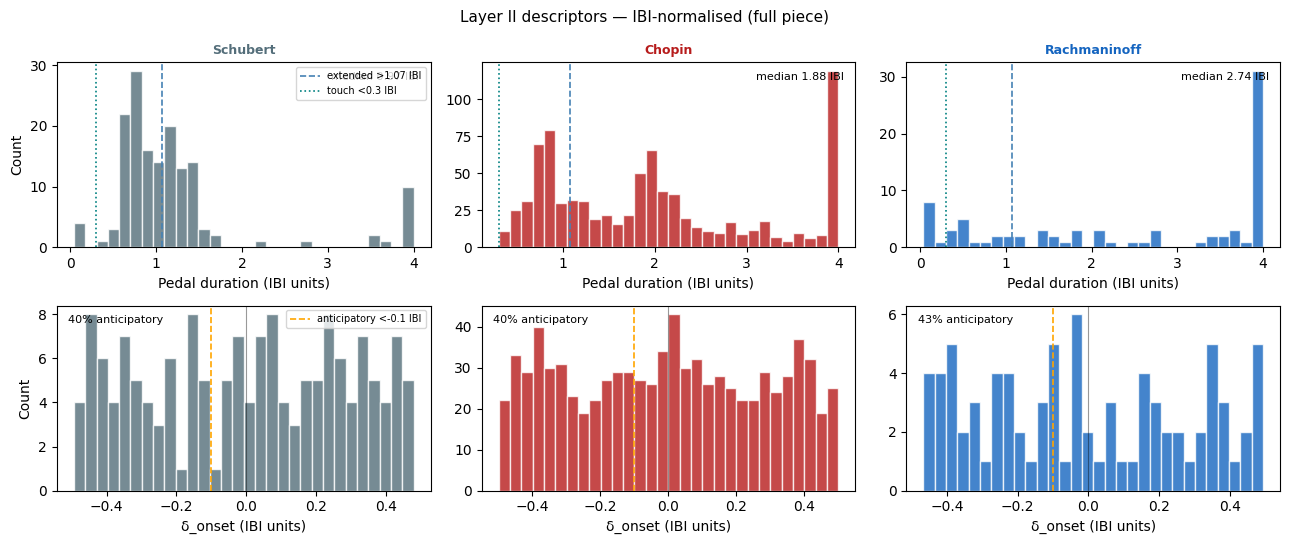

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 5.5))
fig.suptitle('Layer II descriptors — IBI-normalised (full piece)', fontsize=11)

for col, p in enumerate(PIECES):
    r = results[p['short']]
    evs = r['events']
    durs = np.array([e.dur_ibi      for e in evs if e.dur_ibi      is not None])
    d_on = np.array([e.delta_onset  for e in evs if e.delta_onset  is not None])

    ax = axes[0, col]
    ax.hist(np.clip(durs, 0, 4), bins=30, color=p['color'], edgecolor='white', alpha=0.8)
    ax.axvline(_DUR_SUSTAIN,   color='steelblue', lw=1.2, ls='--',
               label=f'extended >{_DUR_SUSTAIN} IBI')
    ax.axvline(_DUR_TOUCH_IBI, color='teal',      lw=1.2, ls=':',
               label=f'touch <{_DUR_TOUCH_IBI} IBI')
    ax.set_xlabel('Pedal duration (IBI units)')
    ax.set_title(p['short'], fontsize=9, color=p['color'], fontweight='bold')
    if col == 0:
        ax.set_ylabel('Count')
        ax.legend(fontsize=7)
    ax.text(0.97, 0.95, f'median {np.median(durs):.2f} IBI',
            transform=ax.transAxes, ha='right', va='top', fontsize=8)

    ax = axes[1, col]
    ax.hist(np.clip(d_on, -1.5, 1.5), bins=30, color=p['color'], edgecolor='white', alpha=0.8)
    ax.axvline(_DON_ANTICIPATE, color='orange', lw=1.2, ls='--',
               label=f'anticipatory <{_DON_ANTICIPATE} IBI')
    ax.axvline(0, color='k', lw=0.8, ls='-', alpha=0.4)
    ax.set_xlabel('δ_onset (IBI units)')
    if col == 0:
        ax.set_ylabel('Count')
        ax.legend(fontsize=7)
    anti_pct = 100 * np.mean(d_on < _DON_ANTICIPATE)
    ax.text(0.03, 0.95, f'{anti_pct:.0f}% anticipatory',
            transform=ax.transAxes, ha='left', va='top', fontsize=8)

plt.tight_layout()
plt.show()

## A direct comparison: two events that look identical to on/off encoding

Both events below reach near-full depth (CC64 ~= 127).
Binary encoding produces 1 for both; depth analysis says full pedal for both.
Layer II exposes the difference: one is a brief rhythmic Wechselpedal event,
the other is a long anticipatory legato pedal.

In [ ]:
def pick_event(events, dur_lo, dur_hi, lag_lo, lag_hi):
    cands = [e for e in events
             if e.dur_sec is not None
             and dur_lo <= e.dur_sec <= dur_hi
             and lag_lo <= e.lag_sec <= lag_hi
             and e.max_depth >= 0.90]
    return cands[len(cands) // 2] if cands else None

# Schubert: a short rhythmic event (Wechselpedal)
# Chopin: a long anticipatory event
schu_ev = pick_event(results['Schubert']['events'],
                     dur_lo=0.20, dur_hi=0.80, lag_lo=-0.05, lag_hi=0.12)
chop_ev = pick_event(results['Chopin']['events'],
                     dur_lo=0.50, dur_hi=5.00, lag_lo=-0.40, lag_hi=-0.05)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
fig.suptitle('Same binary encoding (CC64 ≈ 127), opposite musical function', fontsize=10)

piece_map = {p['short']: p for p in PIECES}
for ax, ev, short in zip(axes, [schu_ev, chop_ev], ['Schubert', 'Chopin']):
    p = piece_map[short]
    if ev is None:
        ax.text(0.5, 0.5, 'no matching event found', ha='center', va='center')
        continue
    t = ev.times - ev.onset_sec
    ax.fill_between(t, 0, ev.depths, color=p['color'], alpha=0.55)
    ax.plot(t, ev.depths, color=p['color'], lw=1.5)
    ax.axhline(1.0, color='k', lw=0.5, ls=':', alpha=0.4)
    ax.axhline(0.5, color='purple', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlim(min(t) - 0.05, max(t) + 0.05)
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel('Time within event (s)')
    ax.set_ylabel('Depth')
    lbl_str = ', '.join(ev.labels)
    ax.set_title(
        f'{short}\n'
        f'dur={ev.dur_sec:.2f}s  lag={ev.lag_sec*1000:.0f}ms  depth={ev.max_depth:.2f}\n'
        f'Layer III: [{lbl_str}]',
        fontsize=8.5, color=p['color'])

plt.tight_layout()
plt.show()

### Piano roll + Layer III label strip + audio

Each column shows a ±3 s context window around the highlighted event (dashed lines).
Grey verticals mark beat positions from the MIDI tempo map.

- **Top:** piano roll (note rectangles, opacity ∝ velocity)
- **Middle:** Layer III label strip — every pedal event in the window coloured by its primary label; the highlighted event has a white border
- **Bottom:** CC64 depth trajectory (Layer I)

Audio players below play the same context window from the Maestro WAV recording.

In [ ]:
import matplotlib.gridspec as gridspec
import soundfile as sf
import IPython.display as ipd

_CTX = 3.0   # seconds of context on each side of the highlighted event

LABEL_ABBREV = {
    'rhythmic': 'rhy', 'anticipatory': 'ant', 'extended': 'ext',
    'half-pedal': 'hpd', 'touch': 'tch', 'note-blend': 'nbl', 'other': 'oth',
}

def _notes_in_window(midi_path, t0, t1):
    pm = pretty_midi.PrettyMIDI(midi_path)
    notes = [n for inst in pm.instruments if not inst.is_drum
             for n in inst.notes if n.end >= t0 and n.start <= t1]
    beats = pm.get_beats()
    return notes, beats[(beats >= t0) & (beats <= t1)]

def _primary_label(ev):
    """Primary label, skipping note-blend (AR proxy is approximate)."""
    non_nb = [l for l in ev.labels if l != 'note-blend']
    return non_nb[0] if non_nb else (ev.labels[0] if ev.labels else 'other')

fig = plt.figure(figsize=(13, 7.5))
gs  = gridspec.GridSpec(3, 2, hspace=0.05, wspace=0.38, height_ratios=[3, 0.65, 1.1])
ax_rolls  = [fig.add_subplot(gs[0, c]) for c in range(2)]
ax_labels = [fig.add_subplot(gs[1, c], sharex=ax_rolls[c]) for c in range(2)]
ax_peds   = [fig.add_subplot(gs[2, c], sharex=ax_rolls[c]) for c in range(2)]
fig.suptitle('Piano roll + pedal depth — same binary value, different musical function',
             fontsize=11)

for col, (ev, short) in enumerate([(schu_ev, 'Schubert'), (chop_ev, 'Chopin')]):
    if ev is None:
        ax_rolls[col].text(0.5, 0.5, 'no event', ha='center', va='center')
        continue
    p = piece_map[short]
    r = results[short]

    t0_abs = ev.onset_sec - _CTX
    t1_abs = ev.offset_sec + _CTX
    ev_x0  = ev.onset_sec  - t0_abs
    ev_x1  = ev.offset_sec - t0_abs

    notes, beat_times = _notes_in_window(p['midi'], t0_abs, t1_abs)
    beat_rel = beat_times - t0_abs

    pitches = [n.pitch for n in notes]
    p_lo = max(min(pitches) - 3, 0)    if pitches else 48
    p_hi = min(max(pitches) + 3, 127)  if pitches else 84

    # ── Piano roll ──
    axr = ax_rolls[col]
    for n in notes:
        axr.add_patch(mpatches.Rectangle(
            (n.start - t0_abs, n.pitch - 0.4), n.end - n.start, 0.8,
            color=p['color'], alpha=0.35 + 0.55 * (n.velocity / 127),
            linewidth=0, zorder=2
        ))
    for bt in beat_rel:
        axr.axvline(bt, color='#90A4AE', lw=0.5, alpha=0.40, zorder=1)
    axr.axvspan(ev_x0, ev_x1, color=p['color'], alpha=0.10, zorder=0)
    axr.axvline(ev_x0, color=p['color'], lw=1.3, ls='--', alpha=0.85, label='highlighted event')
    axr.axvline(ev_x1, color=p['color'], lw=1.3, ls='--', alpha=0.85)
    axr.set_xlim(0, t1_abs - t0_abs)
    axr.set_ylim(p_lo - 0.5, p_hi + 0.5)
    axr.set_ylabel('Pitch')
    ticks = list(range(int(p_lo // 12) * 12, p_hi + 1, 12))
    axr.set_yticks(ticks)
    axr.set_yticklabels([pretty_midi.note_number_to_name(t) for t in ticks], fontsize=8)
    lbl_str = ', '.join(ev.labels)
    axr.set_title(
        f'{short}  [{lbl_str}]\n'
        f'dur={ev.dur_sec:.2f}s  δ_onset={ev.delta_onset:.2f} IBI  depth={ev.max_depth:.2f}',
        fontsize=9, color=p['color'], fontweight='bold'
    )
    axr.tick_params(labelbottom=False)
    axr.legend(fontsize=7, loc='upper right')

    # ── Label strip: all events in the context window ──
    ctx_events = sorted(
        [e for e in r['events'] if e.onset_sec < t1_abs and e.offset_sec > t0_abs],
        key=lambda e: e.onset_sec
    )
    axl = ax_labels[col]
    axl.set_ylim(0, 1)
    axl.set_yticks([])
    axl.set_ylabel('Label (III)', fontsize=7)
    axl.tick_params(labelbottom=False)

    used_labels = set()
    for ev_ctx in ctx_events:
        x0 = max(ev_ctx.onset_sec, t0_abs) - t0_abs
        x1 = min(ev_ctx.offset_sec, t1_abs) - t0_abs
        primary = _primary_label(ev_ctx)
        used_labels.add(primary)
        c = LABEL_COLORS.get(primary, '#90A4AE')
        is_hi = ev_ctx is ev
        axl.barh(0.5, x1 - x0, left=x0, height=0.75,
                 color=c, alpha=0.95 if is_hi else 0.65,
                 linewidth=2.0 if is_hi else 0,
                 edgecolor='white', zorder=3 if is_hi else 2)
        if x1 - x0 > 0.12:
            axl.text((x0 + x1) / 2, 0.5, LABEL_ABBREV.get(primary, primary[:3]),
                     ha='center', va='center', fontsize=5.5,
                     color='white', fontweight='bold', zorder=4)

    patches_legend = [mpatches.Patch(color=LABEL_COLORS.get(l, '#90A4AE'),
                                     label=f'{LABEL_ABBREV.get(l, l)}: {l}')
                      for l in sorted(used_labels)]
    axl.legend(handles=patches_legend, loc='center right', fontsize=5,
               ncol=1, framealpha=0.88, handlelength=1.0, borderpad=0.4)

    # ── Pedal depth (Layer I) ──
    axp = ax_peds[col]
    mask = (r['t_raw'] >= t0_abs) & (r['t_raw'] <= t1_abs)
    t_rel = r['t_raw'][mask] - t0_abs
    v_rel = r['v_raw'][mask]
    axp.fill_between(t_rel, 0, v_rel, color=p['color'], alpha=0.28)
    axp.plot(t_rel, v_rel, color=p['color'], lw=0.9)
    axp.axhline(0.5, color='purple', lw=0.7, ls='--', alpha=0.4)
    for bt in beat_rel:
        axp.axvline(bt, color='#90A4AE', lw=0.5, alpha=0.40, zorder=0)
    axp.axvspan(ev_x0, ev_x1, color=p['color'], alpha=0.10, zorder=0)
    axp.axvline(ev_x0, color=p['color'], lw=1.3, ls='--', alpha=0.85)
    axp.axvline(ev_x1, color=p['color'], lw=1.3, ls='--', alpha=0.85)
    axp.set_ylim(-0.05, 1.12)
    axp.set_yticks([0, 0.5, 1.0])
    axp.set_ylabel('Depth (I)')
    axp.set_xlabel('Time in context (s)')

plt.savefig('../figures/comparison_piano_roll.pdf', bbox_inches='tight', dpi=150)
plt.show()

# ── Audio: same ±_CTX s window as the piano roll ──
for ev, short, label in [(schu_ev, 'Schubert', 'rhythmic'),
                          (chop_ev, 'Chopin',   'anticipatory')]:
    if ev is None:
        continue
    wav = piece_map[short]['midi'].replace('.midi', '.wav')
    if not Path(wav).exists():
        print(f'  [skip] {short}: WAV not found')
        continue
    t0 = max(0.0, ev.onset_sec - _CTX)
    t1 = ev.offset_sec + _CTX
    info = sf.info(wav)
    sr   = info.samplerate
    audio, _ = sf.read(wav, start=int(t0 * sr), stop=int(t1 * sr), always_2d=True)
    print(f'▶  {short} [{label}]  onset={ev.onset_sec:.1f}s'
          f'  δ_onset={ev.delta_onset:.2f} IBI  dur={ev.dur_sec:.2f}s')
    ipd.display(ipd.Audio(audio.T, rate=sr))

## Layer III — semantic label distributions

Assigning beat-aligned IBI-normalised labels to all events:

* **Schubert** — mostly *rhythmic*: short, on-beat, released before the next beat (δ_onset ≈ 0, δ_offset < 0)
* **Chopin** — *anticipatory* + *extended*: pressed well before the beat, held past the next
* **Rachmaninoff** — *extended*: dur_ibi >> 1 beat; dense harmonic textures sustained across many beats
* **note-blend** appears wherever the voice-agnostic AR approximation exceeds the Mozart p75 (AR > 2.68)

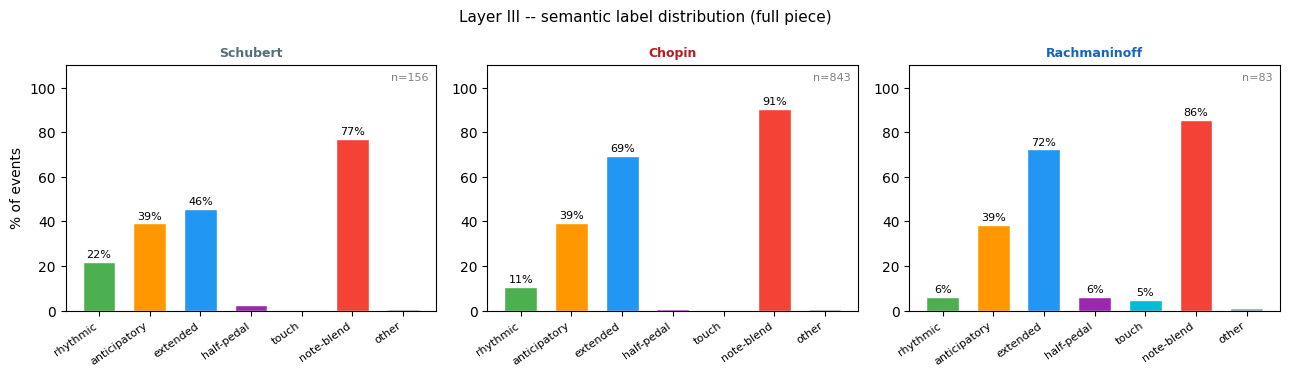

In [9]:
label_order = ['rhythmic', 'anticipatory', 'extended', 'half-pedal', 'touch', 'note-blend', 'other']

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
fig.suptitle('Layer III -- semantic label distribution (full piece)', fontsize=11)

for ax, p in zip(axes, PIECES):
    r = results[p['short']]
    evs = r['events']
    n = len(evs)
    counts = Counter(lbl for e in evs for lbl in e.labels)
    pcts   = [100 * counts.get(lbl, 0) / n for lbl in label_order]
    colors = [LABEL_COLORS[lbl] for lbl in label_order]
    bars = ax.bar(label_order, pcts, color=colors, edgecolor='white', width=0.65)
    for bar, pct in zip(bars, pcts):
        if pct > 4:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.0, f'{pct:.0f}%',
                    ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, 110)
    if ax is axes[0]:
        ax.set_ylabel('% of events')
    ax.set_xticklabels(label_order, rotation=35, ha='right', fontsize=8)
    ax.set_title(p['short'], fontsize=9, color=p['color'], fontweight='bold')
    ax.text(0.98, 0.97, f'n={n}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='grey')

plt.tight_layout()
plt.show()

## Combined encoding-space view

Plotting every pedal event in **duration x lag** space reveals three well-separated
clusters. Binary on/off collapses all of this to one dimension (duration alone);
depth analysis adds one dimension but misses the timing axis entirely.

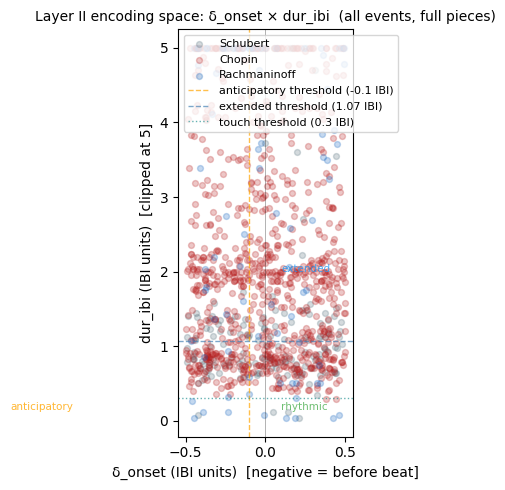

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for p in PIECES:
    r = results[p['short']]
    evs = r['events']
    d_on = np.array([e.delta_onset for e in evs if e.delta_onset is not None])
    durs = np.array([e.dur_ibi     for e in evs if e.dur_ibi     is not None])
    ax.scatter(np.clip(d_on, -2, 2), np.clip(durs, 0, 5),
               c=p['color'], alpha=0.25, s=18, label=p['short'], rasterized=True)

ax.axvline(_DON_ANTICIPATE, color='orange',     lw=1, ls='--', alpha=0.7,
           label=f'anticipatory threshold ({_DON_ANTICIPATE} IBI)')
ax.axvline(0,               color='k',          lw=0.7, ls='-', alpha=0.3)
ax.axhline(_DUR_SUSTAIN,    color='steelblue',  lw=1, ls='--', alpha=0.7,
           label=f'extended threshold ({_DUR_SUSTAIN} IBI)')
ax.axhline(_DUR_TOUCH_IBI,  color='teal',       lw=1, ls=':',  alpha=0.6,
           label=f'touch threshold ({_DUR_TOUCH_IBI} IBI)')
ax.text(-1.6, 0.15, 'anticipatory',  fontsize=7.5, color='orange',    alpha=0.8)
ax.text( 0.1, 0.15, 'rhythmic',      fontsize=7.5, color='#4CAF50',   alpha=0.8)
ax.text( 0.1, 2.0,  'extended',      fontsize=7.5, color='#2196F3',   alpha=0.8)
ax.set_xlabel('δ_onset (IBI units)  [negative = before beat]')
ax.set_ylabel('dur_ibi (IBI units)  [clipped at 5]')
ax.set_title('Layer II encoding space: δ_onset × dur_ibi  (all events, full pieces)', fontsize=10)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## Aligned views (Layer I depth + Layer III labels + Layer II lag)

Each piece gets a **three-panel aligned view**:
1. **CC64 depth (Layer I)** — continuous pedal depth; grey ticks = note onsets
2. **Semantic label bands (Layer III)** — colour-coded by label
3. **Pedal-to-note lag scatter (Layer II)** — each dot = one event

Note that:
* **Beethoven**: short events, all on-beat → almost entirely *rhythmic*
* **Chopin**: long events with notable anticipatory dips below the −70 ms threshold
* **Debussy**: mixed depth — purple half-pedal events appear only here

In [11]:
def plot_aligned_view(r, title_extra=''):
    """Three-panel aligned view (MIDI-only; beat-aligned Layer II)."""
    p   = r['piece']
    T0, T1 = p['T0'], p['T1']
    evs   = [e for e in r['events'] if e.onset_sec < T1 and e.offset_sec > T0]
    beats = r.get('beats', np.array([]))

    fig, axes = plt.subplots(
        3, 1, figsize=(13, 7.5), sharex=True,
        gridspec_kw={'height_ratios': [2.4, 1.0, 1.6]}
    )
    fig.suptitle(f'{p["name"]}{title_extra}  ({T0:.0f}–{T1:.0f} s)', fontsize=10)

    # Panel 0: CC64 depth (Layer I) + beat ticks
    ax = axes[0]
    mask = (r['t_raw'] >= T0) & (r['t_raw'] <= T1)
    ax.plot(r['t_raw'][mask], r['v_raw'][mask], lw=0.9, color=p['color'])
    ax.fill_between(r['t_raw'][mask], 0, r['v_raw'][mask],
                    color=p['color'], alpha=0.22)
    ax.axhline(0.50, color='purple', lw=0.7, ls='--', alpha=0.5,
               label='half-pedal threshold (0.50)')
    # note onsets
    n_mask = (r['note_ons'] >= T0) & (r['note_ons'] <= T1)
    for t in r['note_ons'][n_mask]:
        ax.axvline(t, ymin=0, ymax=0.07, color='#37474F', lw=0.35, alpha=0.35)
    # beat grid
    b_mask = (beats >= T0) & (beats <= T1)
    for t in beats[b_mask]:
        ax.axvline(t, ymin=0.88, ymax=1.0, color='#B71C1C', lw=0.5, alpha=0.55)
    ax.set_ylabel('Depth (Layer I)')
    ax.set_ylim(-0.05, 1.12)
    ax.legend(fontsize=7, loc='lower right')

    # Panel 1: Layer III label bands
    ax = axes[1]
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    for ev in evs:
        x0 = max(ev.onset_sec, T0)
        x1 = min(ev.offset_sec, T1)
        primary = ev.labels[0] if ev.labels else 'other'
        ax.barh(0.5, x1 - x0, left=x0, height=0.72,
                color=LABEL_COLORS.get(primary, '#90A4AE'), alpha=0.85)
        if x1 - x0 > 0.40:
            ax.text((x0 + x1) / 2, 0.5, primary,
                    ha='center', va='center', fontsize=6,
                    color='white', fontweight='bold')
    ax.set_ylabel('Label (III)')
    patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=7, ncol=4,
              framealpha=0.88)

    # Panel 2: δ_onset (IBI-normalised)
    ax = axes[2]
    for ev in evs:
        if ev.delta_onset is not None and T0 <= ev.onset_sec <= T1:
            c = LABEL_COLORS.get(ev.labels[0] if ev.labels else 'other', '#90A4AE')
            ax.scatter(ev.onset_sec, ev.delta_onset,
                       color=c, s=22, zorder=3, alpha=0.85)
    ax.axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
    ax.axhline(_DON_ANTICIPATE, color='orange', lw=0.8, ls='--', alpha=0.7,
               label=f'anticipatory threshold ({_DON_ANTICIPATE} IBI)')
    ax.axhline(_DOFF_RHYTHMIC, color='#4CAF50', lw=0.8, ls=':', alpha=0.6,
               label=f'rhythmic δ_offset limit ({_DOFF_RHYTHMIC} IBI)')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('δ_onset (IBI) (II)')

    plt.tight_layout(h_pad=0.4)
    plt.show()

### Schubert — rhythmic Wechselpedal (D850)

Short, on-beat events lifted at every harmonic change.
Layer III is 100% *rhythmic* in this window — the clearest example in all of Maestro.

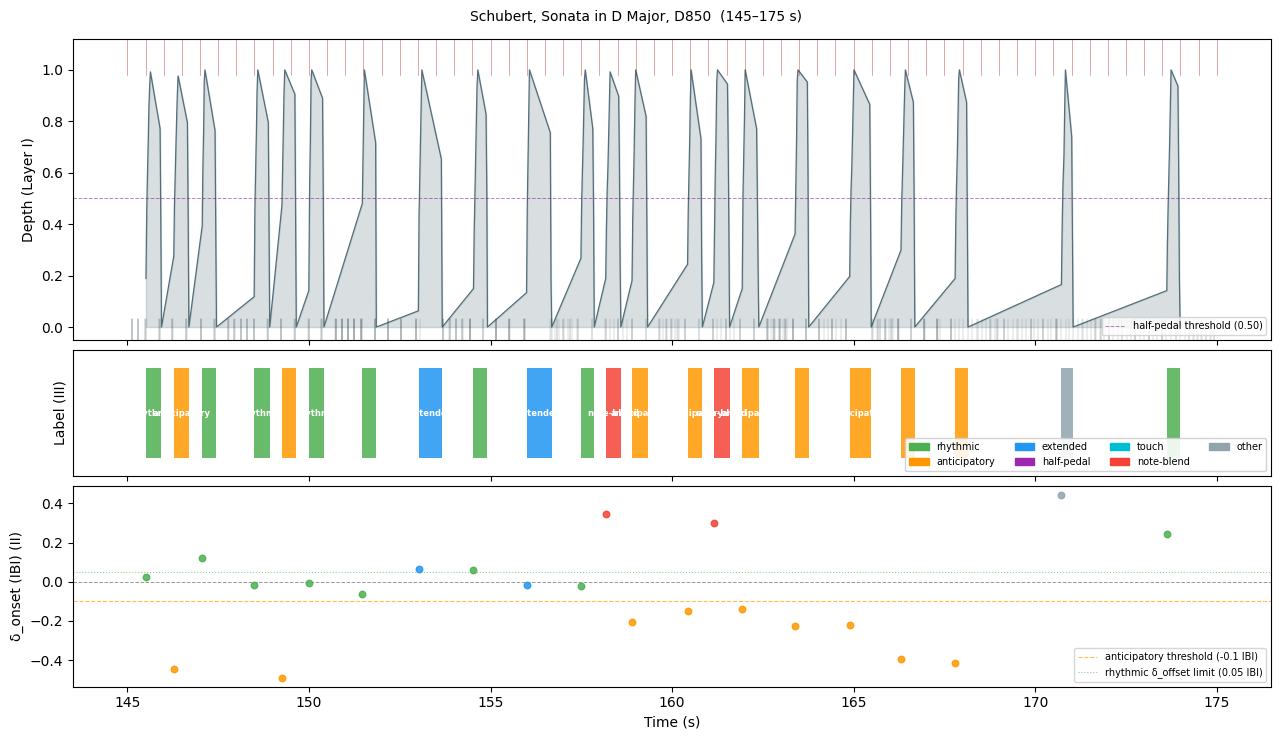

In [12]:
plot_aligned_view(results['Schubert'])

In [13]:
# Audio not available locally (Maestro WAV files not stored on this machine).

### Chopin — anticipatory legato (Sonata No. 2, Op. 35)

Pedal depressed clearly before the note onset (lag < −70 ms) to carry harmony
across phrase boundaries.  100% anticipatory in this window.

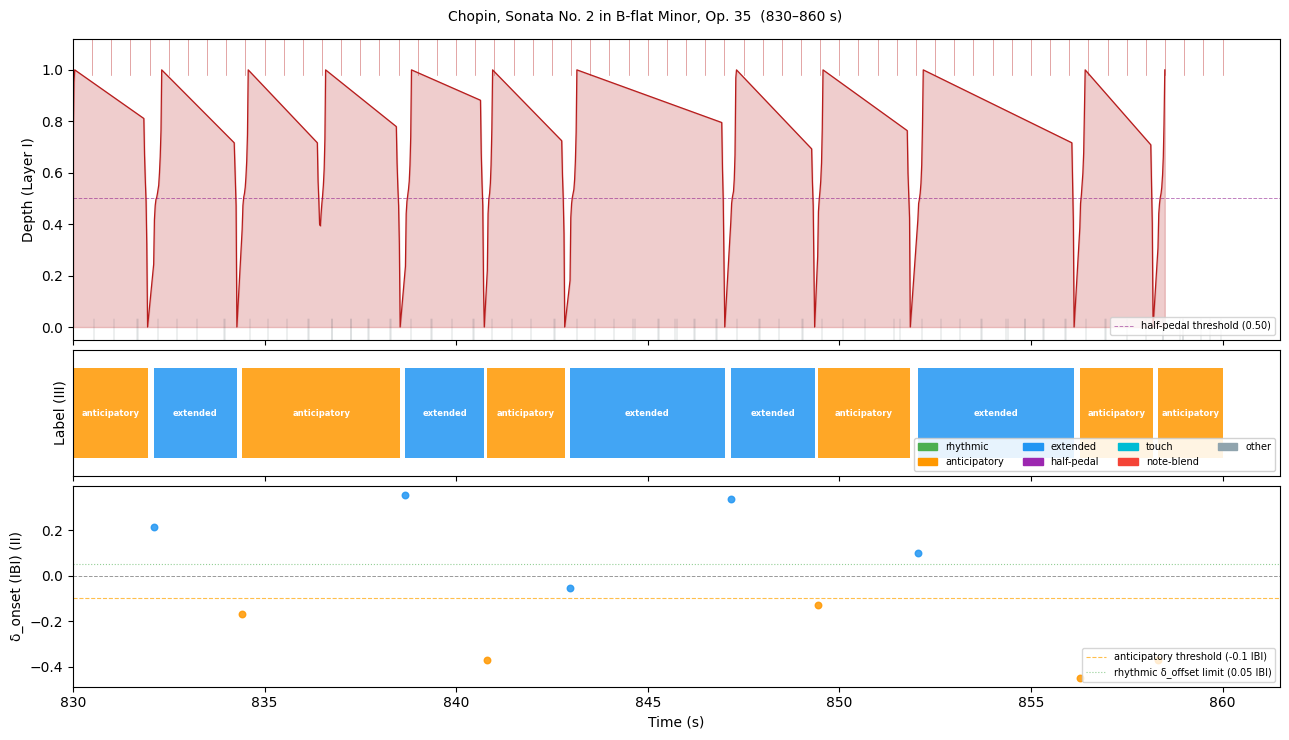

In [14]:
plot_aligned_view(results['Chopin'])

In [15]:
# Audio not available locally (Maestro WAV files not stored on this machine).

### Rachmaninoff — extended sustain (Etude-Tableaux Op. 39 No. 8)

Long full-depth pedals (dur > 1.20 s) sustain dense harmonic textures.
12 consecutive extended events in 30 seconds — 100% pure.

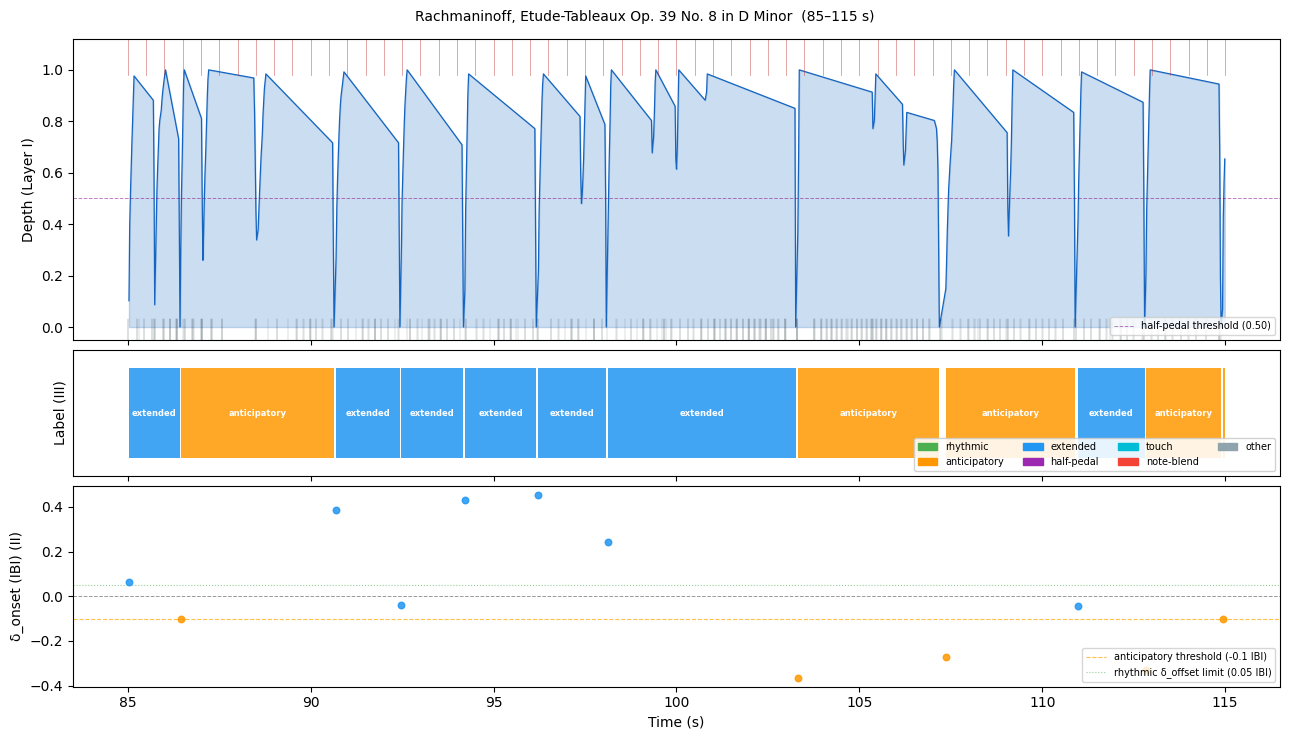

In [16]:
plot_aligned_view(results['Rachmaninoff'])

In [17]:
# Audio not available locally (Maestro WAV files not stored on this machine).

## What this demo shows

| Analysis level | Schubert vs Chopin | Schubert vs Rachmaninoff |
|----------------|--------------------|-----------------------|
| Binary on/off  | indistinguishable | indistinguishable |
| Max depth only | both ≈ 1.0 — indistinguishable | both ≈ 1.0 — indistinguishable |
| Layer I depth trajectory | similar full-depth shape | similar full-depth shape |
| Layer II (dur + lag) | Schubert: short + on-beat; Chopin: long + before note | Schubert: short; Rachmaninoff: long + on/after beat |
| Layer III semantic | Schubert: *rhythmic*; Chopin: *anticipatory* | Schubert: *rhythmic*; Rachmaninoff: *extended* |

The three-layer encoding surfaces musically distinct functions from a single CC64 stream —
something that neither on/off nor depth thresholding alone can achieve.

These three pieces were selected by scanning all 2552 MIDI files in MAESTRO v3 and
maximising label purity in the best 30-second window.  See the **Supplementary**
section for the full per-label top-10 rankings.

## Full-piece statistics summary

In [18]:
LABEL_ORDER = ['rhythmic', 'anticipatory', 'extended', 'half-pedal', 'touch', 'note-blend', 'other']

print(f'{"Piece":<12} {"N":>5}  {"dur_med(IBI)":>13}  {"δon_med":>9}  '
      f'{"depth_mean":>11}  {"half%":>6}  {"anti%":>6}')
print('─' * 82)

piece_stats = {}
for short, r in results.items():
    evs  = r['events']
    n    = len(evs)
    durs = np.array([e.dur_ibi    for e in evs if e.dur_ibi    is not None])
    deps = np.array([e.max_depth  for e in evs if e.max_depth  is not None])
    d_on = np.array([e.delta_onset for e in evs if e.delta_onset is not None])
    half_pct = 100 * np.mean(deps < _DEPTH_HALF)
    anti_pct = 100 * np.mean(d_on < _DON_ANTICIPATE)
    counts   = Counter(lbl for e in evs for lbl in e.labels)
    piece_stats[short] = dict(n=n, durs=durs, deps=deps, d_on=d_on, counts=counts)
    print(f'{short:<12} {n:>5}  {np.median(durs):>12.2f}x  '
          f'{np.median(d_on):>8.3f}  '
          f'{np.mean(deps):>10.3f}  '
          f'{half_pct:>5.1f}%  {anti_pct:>5.1f}%')

print()
print(f'{"Piece":<12}', '  '.join(f'{l:>11}' for l in LABEL_ORDER))
print('─' * (12 + 13 * len(LABEL_ORDER)))
for short, st in piece_stats.items():
    n = st['n']
    row = '  '.join(
        f'{100 * st["counts"].get(l, 0) / n:>10.1f}%' for l in LABEL_ORDER
    )
    print(f'{short:<12} {row}')

Piece            N   dur_med(IBI)    δon_med   depth_mean   half%   anti%
──────────────────────────────────────────────────────────────────────────────────
Schubert       156          0.97x     0.025       0.966    2.6%   39.7%
Chopin         843          1.88x     0.003       0.961    0.8%   39.5%
Rachmaninoff    83          2.74x    -0.040       0.917    6.0%   43.4%

Piece           rhythmic  anticipatory     extended   half-pedal        touch   note-blend        other
───────────────────────────────────────────────────────────────────────────────────────────────────────
Schubert           21.8%        39.1%        45.5%         2.6%         0.0%        76.9%         0.6%
Chopin             10.8%        39.4%        69.3%         0.8%         0.0%        90.5%         0.6%
Rachmaninoff        6.0%        38.6%        72.3%         6.0%         4.8%        85.5%         1.2%


## Representative segments by label type

For each pedal label, a 30-second sliding window finds the segment with the
highest fraction of that label.  These are the best excerpts to listen to or
visualise to illustrate each function.

Columns: `midi_filename`, `t_start`, `t_end` (seconds), `purity` (% of events
in window carrying the target label), `n_label / n_total`.

In [19]:
def find_best_segment(events, end_time, target_label,
                      window=30.0, min_events=5, step=5.0):
    """Sliding-window search: returns (t_start, t_end, purity, n_label, n_total)."""
    best = None
    t = 0.0
    while t + window <= end_time:
        win = [e for e in events if t <= e.onset_sec < t + window]
        if len(win) >= min_events:
            n_lbl = sum(1 for e in win if target_label in e.labels)
            score = n_lbl / len(win)
            if best is None or score > best[2]:
                best = (t, t + window, score, n_lbl, len(win))
        t += step
    return best


# ---- collect all segments ----
all_segments = []
for p in PIECES:
    r    = results[p['short']]
    evs  = r['events']
    end  = r['end_time']
    midi = Path(p['midi'])

    for lbl in LABEL_ORDER:
        seg = find_best_segment(evs, end, lbl)
        if seg is None:
            continue
        t0, t1, purity, n_lbl, n_tot = seg
        all_segments.append(dict(
            composer=p['short'],
            midi_filename=midi.name,
            midi_path=str(midi),
            label=lbl,
            t_start=round(t0, 1),
            t_end=round(t1, 1),
            purity_pct=round(purity * 100, 1),
            n_label=n_lbl,
            n_total=n_tot,
        ))

# ---- print table ----
hdr = f'{"Composer":<12} {"Label":<14} {"File":<70}  {"t_start":>8}  {"t_end":>7}  {"Purity":>7}  {"n_lbl/tot":>10}'
print(hdr)
print('─' * len(hdr))
prev_lbl = None
for s in sorted(all_segments, key=lambda x: (x['label'], x['composer'])):
    if s['label'] != prev_lbl:
        print()
        prev_lbl = s['label']
    frac = f'{s["n_label"]}/{s["n_total"]}'
    print(f'{s["composer"]:<12} {s["label"]:<14} {s["midi_filename"]:<70}  '
          f'{s["t_start"]:>8.1f}s  {s["t_end"]:>6.1f}s  '
          f'{s["purity_pct"]:>6.1f}%  {frac:>10}')

Composer     Label          File                                                                     t_start    t_end   Purity   n_lbl/tot
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Chopin       anticipatory   ORIG-MIDI_02_7_10_13_Group_MID--AUDIO_14_R3_2013_wav--2.midi               630.0s   660.0s    66.7%         4/6
Rachmaninoff anticipatory   MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi     160.0s   190.0s    66.7%       10/15
Schubert     anticipatory   MIDI-Unprocessed_XP_15_R2_2004_01_ORIG_MID--AUDIO_15_R2_2004_01_Track01_wav.midi      35.0s    65.0s    80.0%         4/5

Chopin       extended       ORIG-MIDI_02_7_10_13_Group_MID--AUDIO_14_R3_2013_wav--2.midi               225.0s   255.0s   100.0%       23/23
Rachmaninoff extended       MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.midi       0.0s    30.0s   1

### Best-segment aligned views

Plot the Layer I / III / II aligned view for the single best representative
segment of each label type, across all three composers.

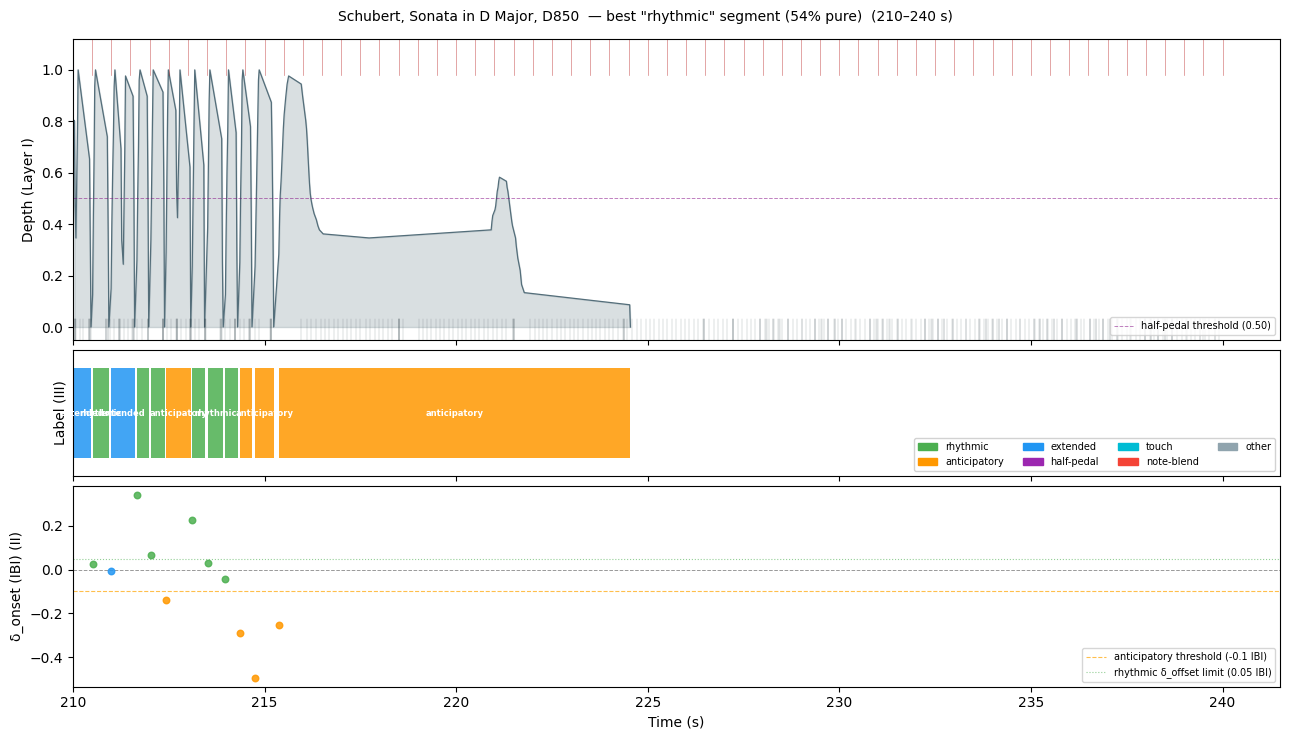

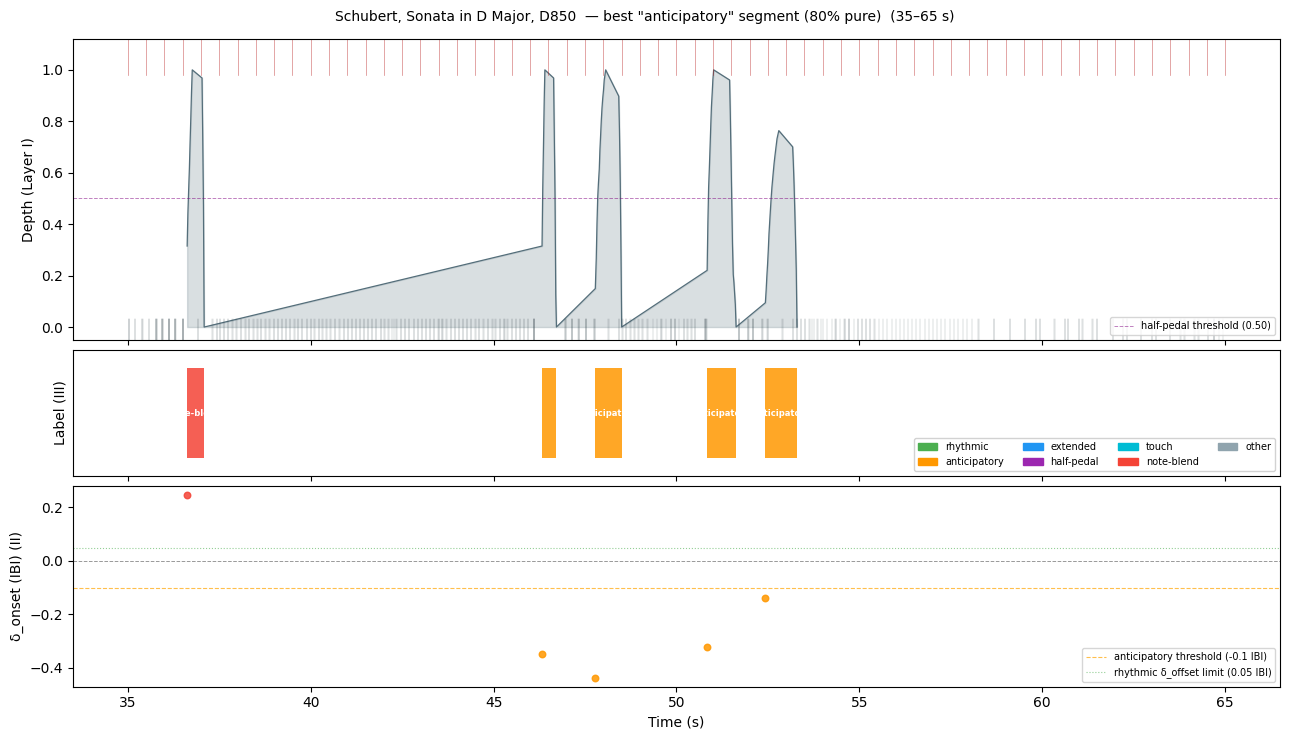

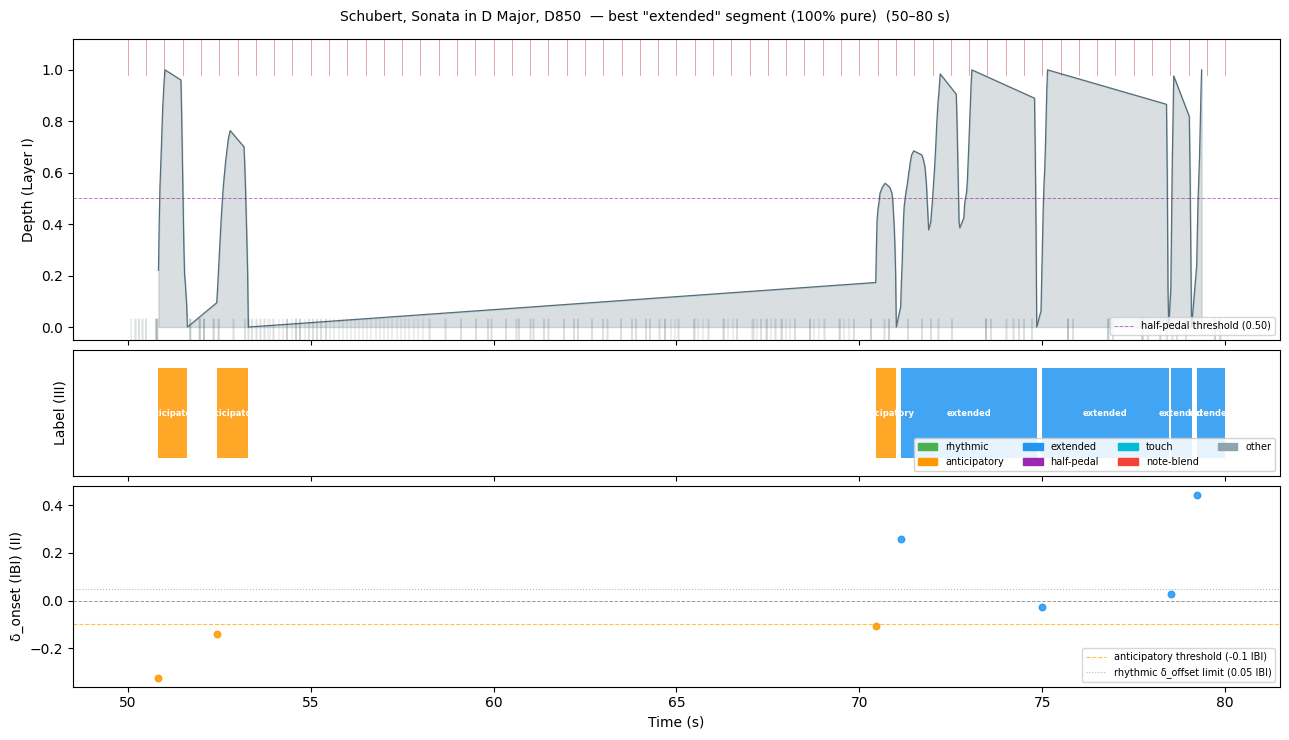

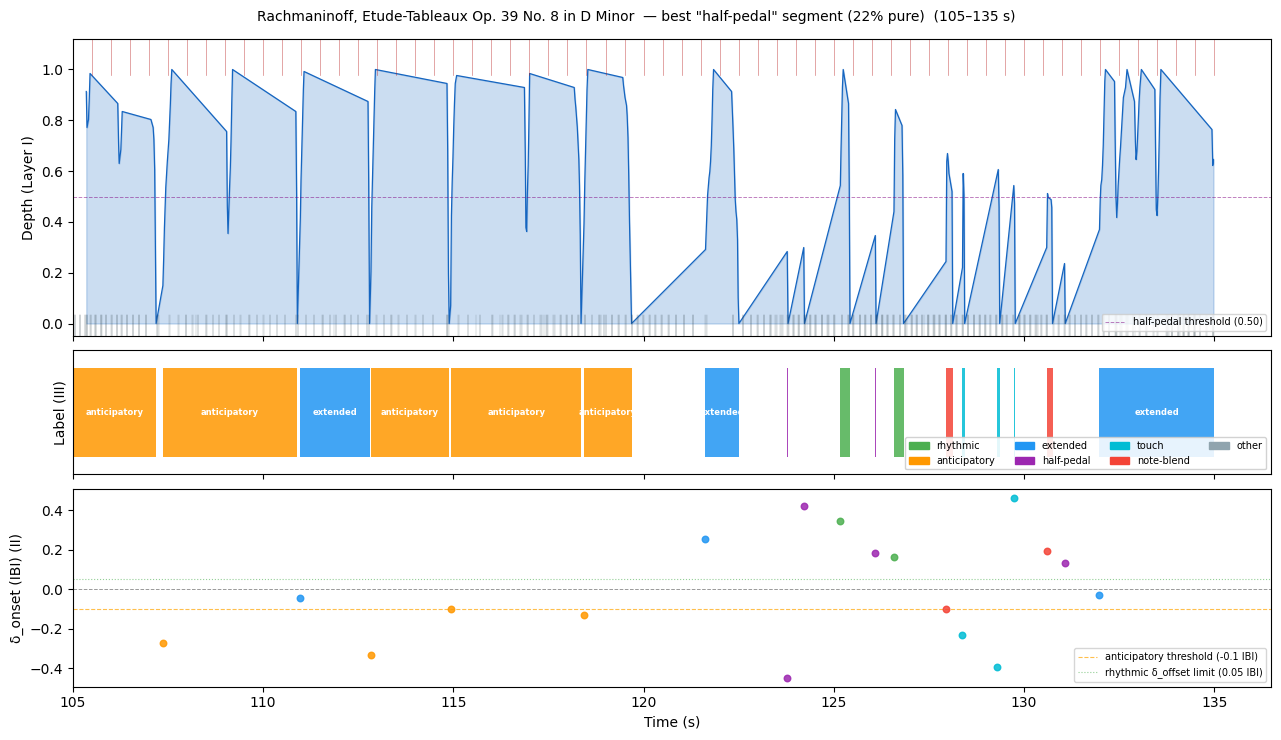

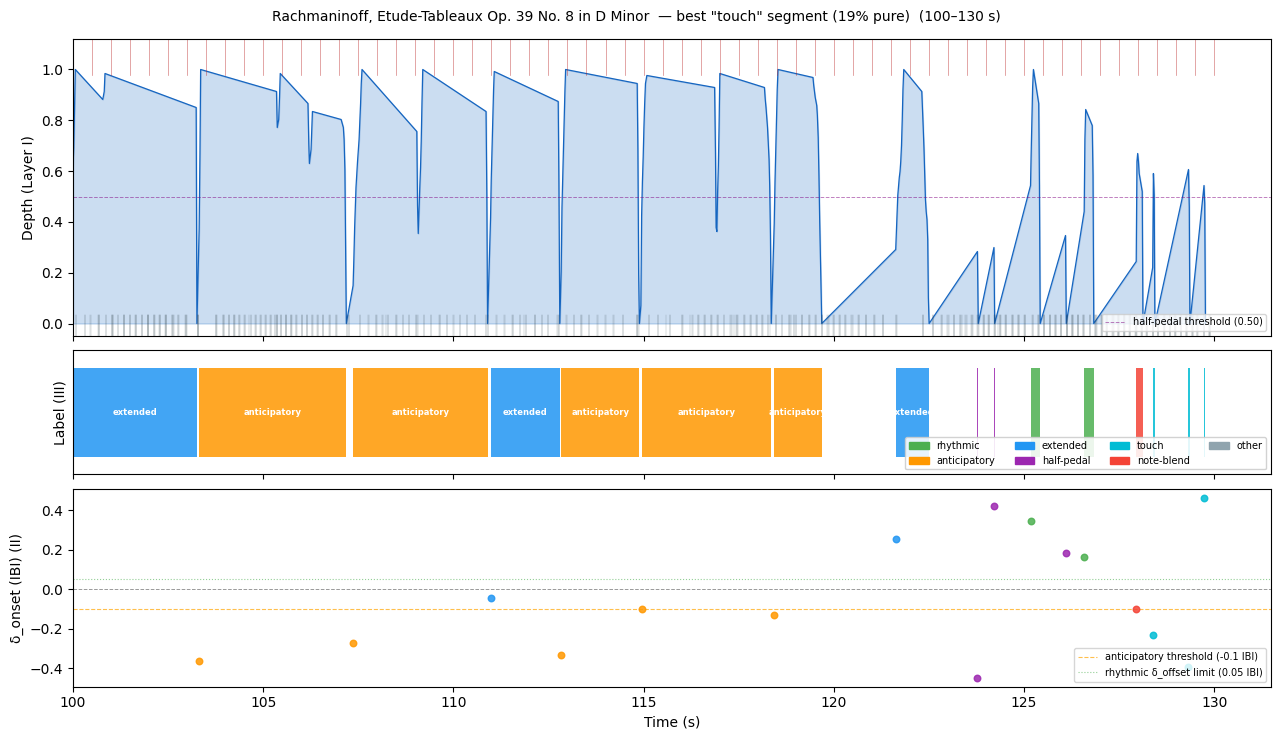

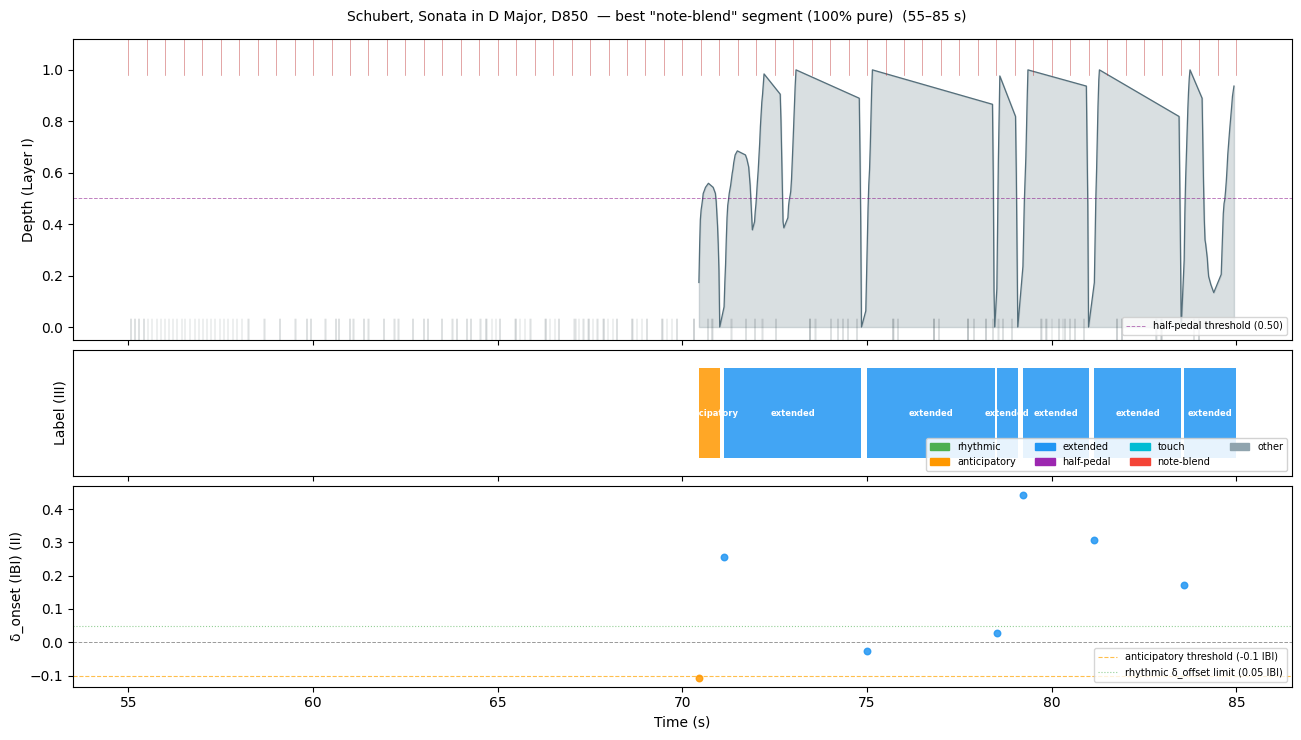

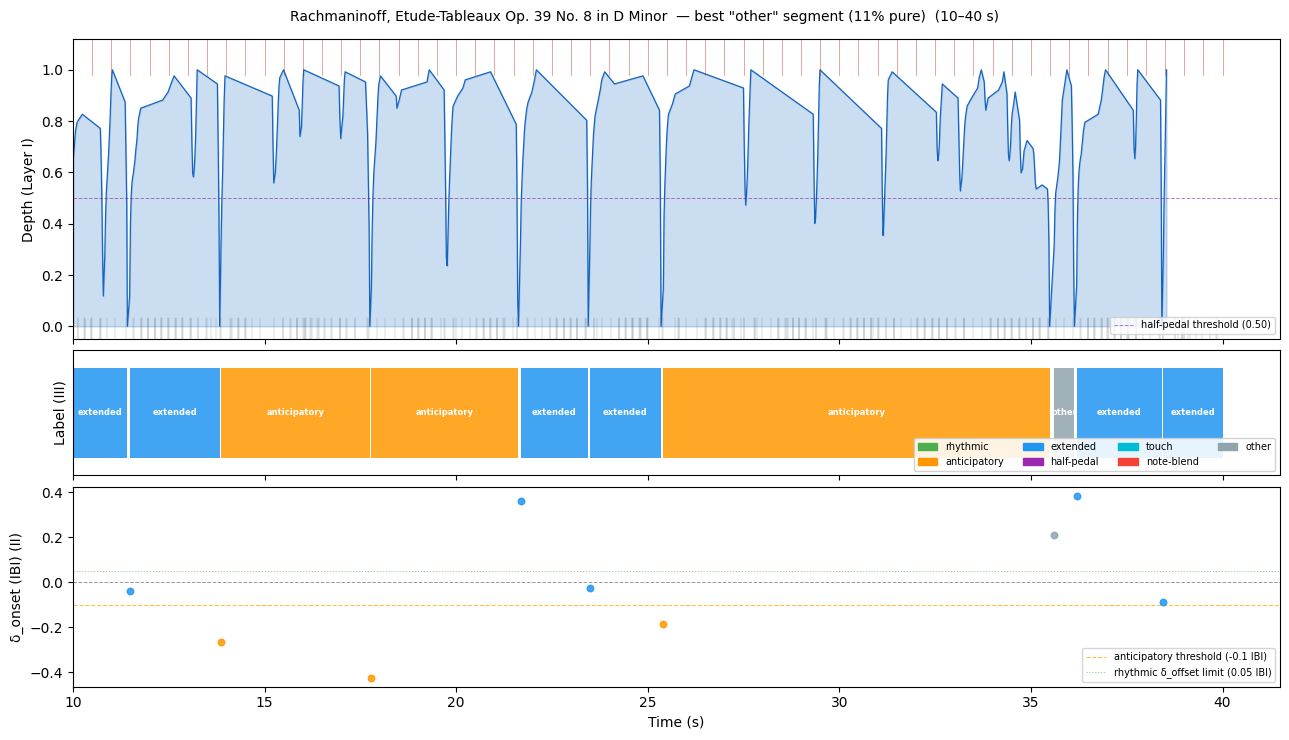

In [20]:
# For each label, pick the single highest-purity segment across all composers
# and render its aligned view.
piece_map = {p['short']: (p, results[p['short']]) for p in PIECES}

for lbl in LABEL_ORDER:
    candidates = [s for s in all_segments if s['label'] == lbl]
    if not candidates:
        continue
    best = max(candidates, key=lambda s: s['purity_pct'])
    if best['purity_pct'] < 10.0:
        continue   # skip trivial segments

    p, r = piece_map[best['composer']]
    # temporarily override T0/T1
    r_tmp = dict(r)
    r_tmp['piece'] = dict(p)
    r_tmp['piece']['T0'] = best['t_start']
    r_tmp['piece']['T1'] = best['t_end']
    plot_aligned_view(r_tmp,
                      title_extra=f'  — best "{lbl}" segment ({best["purity_pct"]:.0f}% pure)')

---
## Supplementary: top-10 segments per label across all of Maestro

The table below ranks every MIDI file in Maestro by the purity of the best
30-second window for each label.  Use these as the gold-standard excerpts
when demonstrating a specific pedal function.

In [21]:
import json

with open('../scripts/best_segments.json') as f:
    best = json.load(f)

for lbl in ['rhythmic', 'anticipatory', 'extended', 'half-pedal', 'touch']:
    entries = best[lbl]
    print(f'\n{"─"*110}')
    print(f'  {lbl.upper():^106}')
    print(f'{"─"*110}')
    print(f'  {"#":>3}  {"Purity":>7}  {"n":>7}  {"t_start":>8}  {"t_end":>7}  '
          f'{"Composer":<35}  {"Title":<45}  MIDI filename')
    print(f'  {"─"*3}  {"─"*7}  {"─"*7}  {"─"*8}  {"─"*7}  '
          f'{"─"*35}  {"─"*45}  {"─"*30}')
    for e in entries:
        frac = f'{e["n_label"]}/{e["n_total"]}'
        print(f'  {e["rank"]:>3}  {e["purity_pct"]:>6.1f}%  {frac:>7}  '
              f'{e["t_start"]:>8.1f}s  {e["t_end"]:>6.1f}s  '
              f'{e["composer"][:35]:<35}  {e["title"][:45]:<45}  '
              f'{e["midi_filename"][:50]}')


──────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                   RHYTHMIC                                                 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
    #   Purity        n   t_start    t_end  Composer                             Title                                          MIDI filename
  ───  ───────  ───────  ────────  ───────  ───────────────────────────────────  ─────────────────────────────────────────────  ──────────────────────────────
    1    80.0%    12/15     280.0s   310.0s  Franz Liszt                          Hungarian Rhapsody No. 9                       MIDI-Unprocessed_04_R1_2008_01-04_ORIG_MID--AUDIO_
    2    78.6%    11/14      25.0s    55.0s  Sergei Rachmaninoff                  Etudes-Tableaux Op. 33                         MIDI-Unprocessed_Recital5-7_MID--AUDIO_05_R1_2018_
    3  


Rendering best "rhythmic": Franz Liszt — Hungarian Rhapsody No. 9  (280.0–310.0s, 80.0% pure)


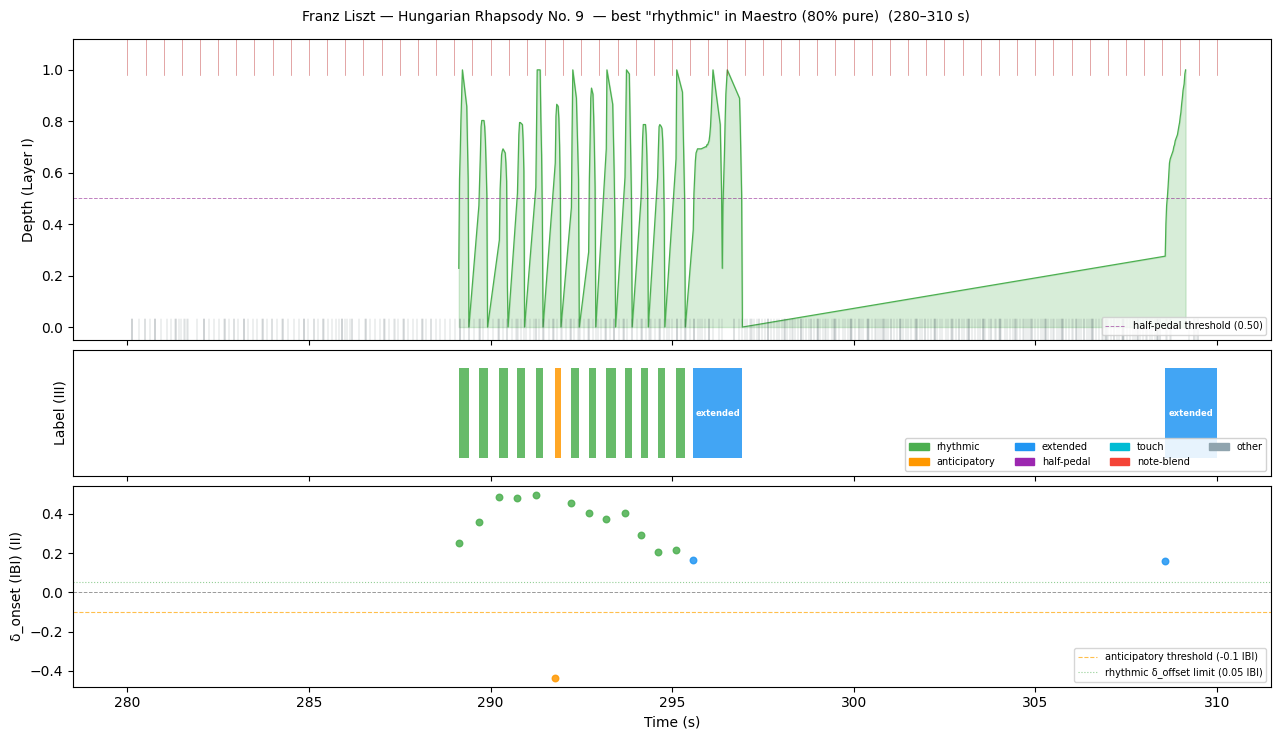


Rendering best "anticipatory": Johann Sebastian Bach — Partita No. 6 in E Minor  (295.0–325.0s, 100.0% pure)


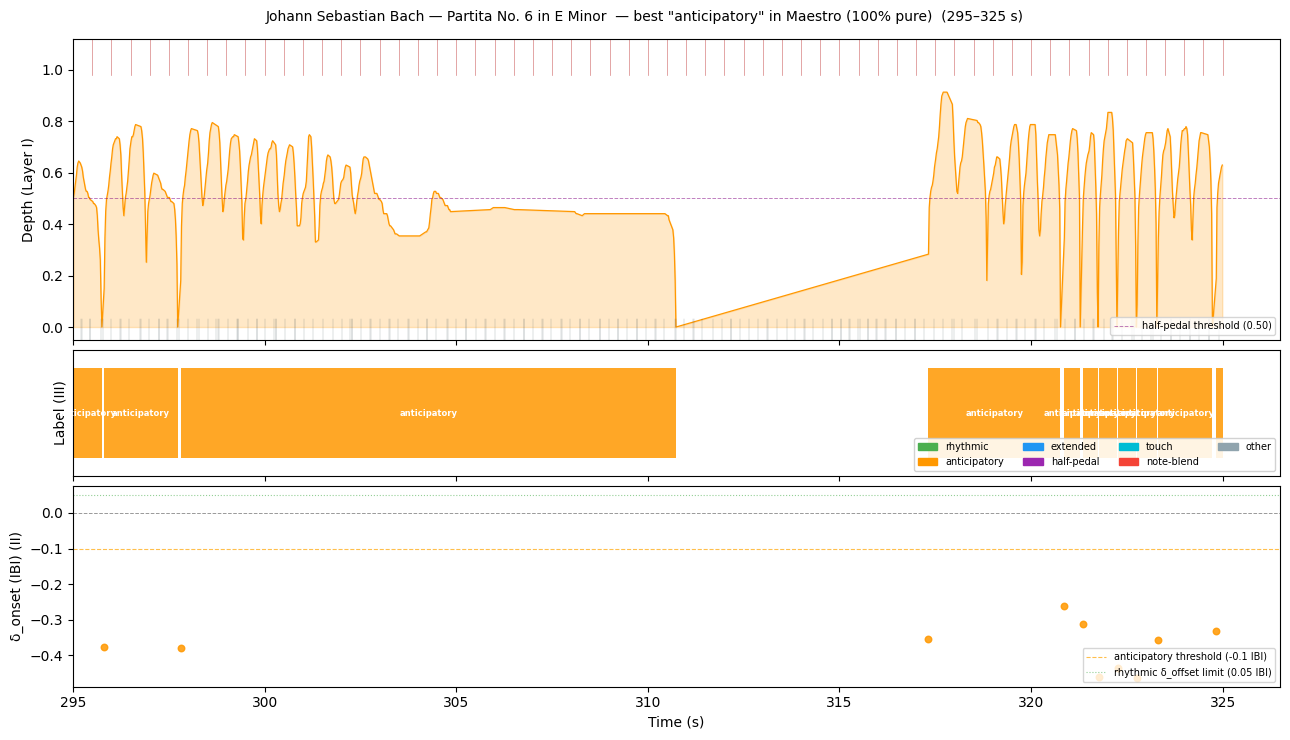


Rendering best "extended": Johann Sebastian Bach — French Suite No. 5 in G Major  (285.0–315.0s, 100.0% pure)


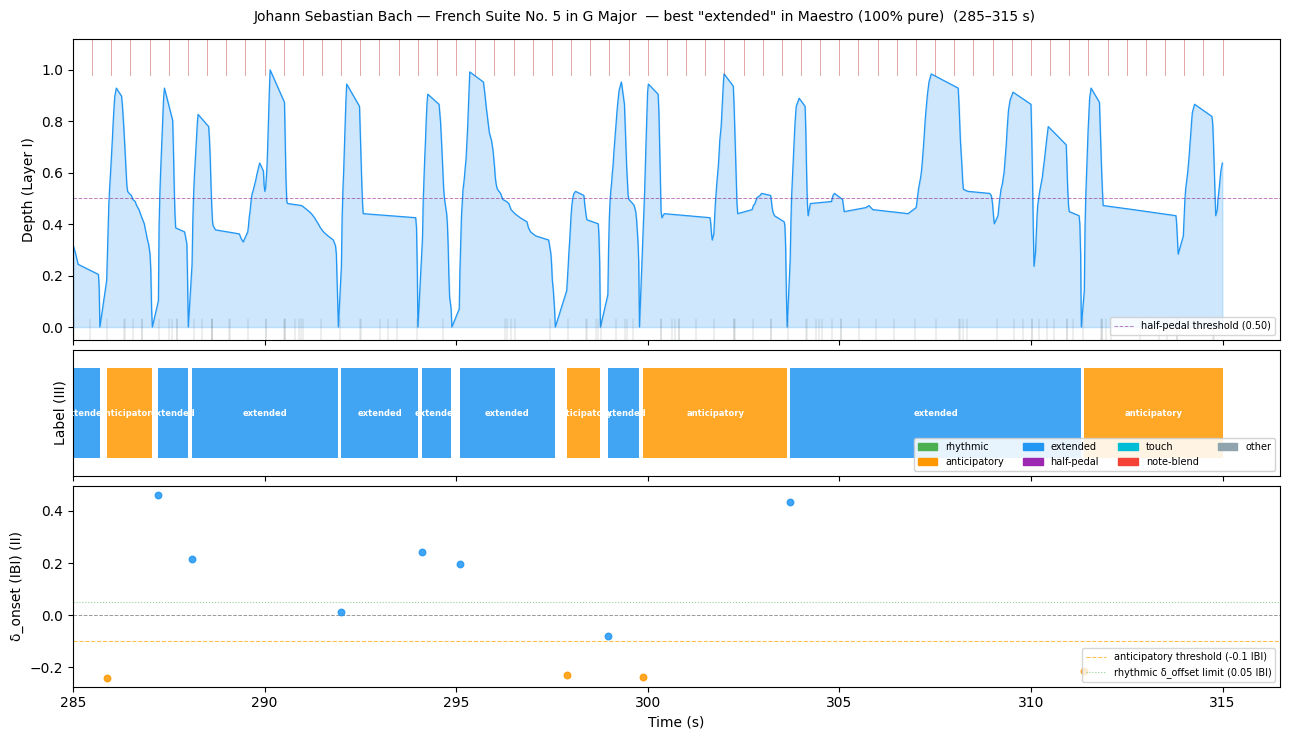


Rendering best "half-pedal": George Frideric Handel — Suite No. 3 in D Minor  (110.0–140.0s, 100.0% pure)


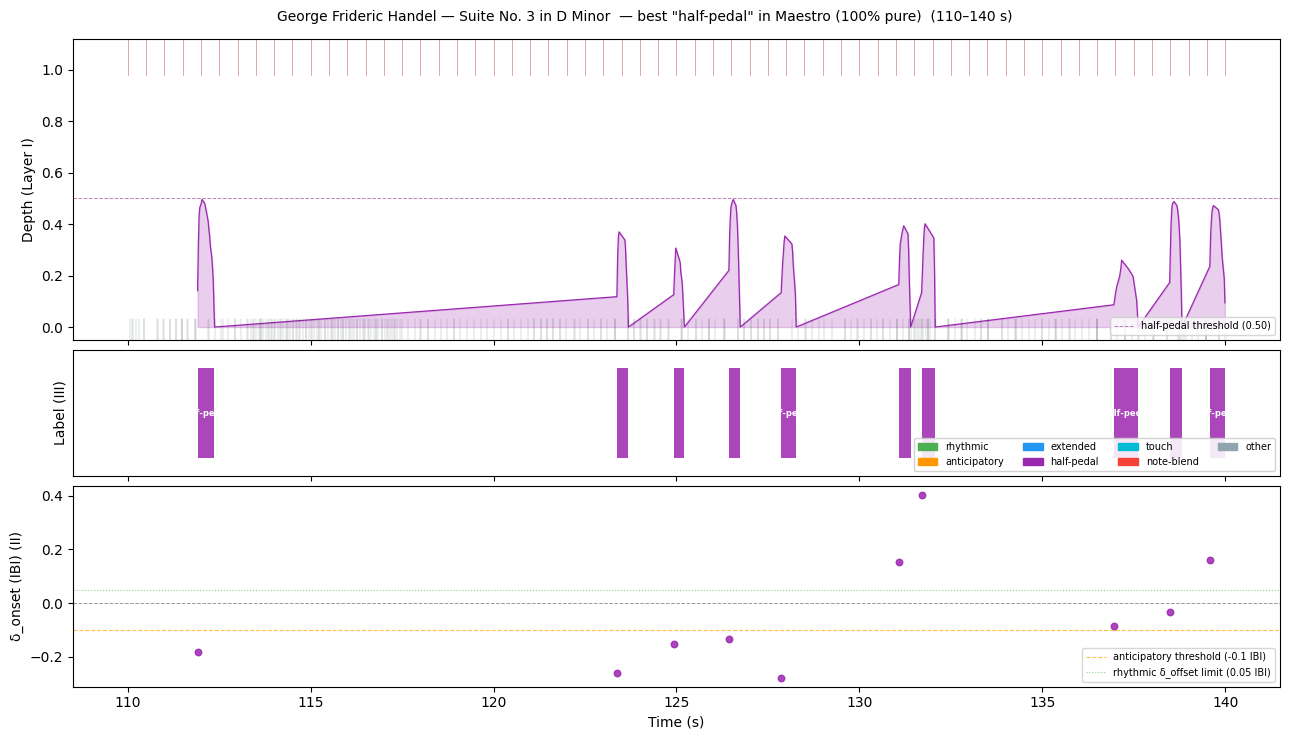


Rendering best "touch": Robert Schumann — Symphonic Etudes, Op. 13  (505.0–535.0s, 85.7% pure)


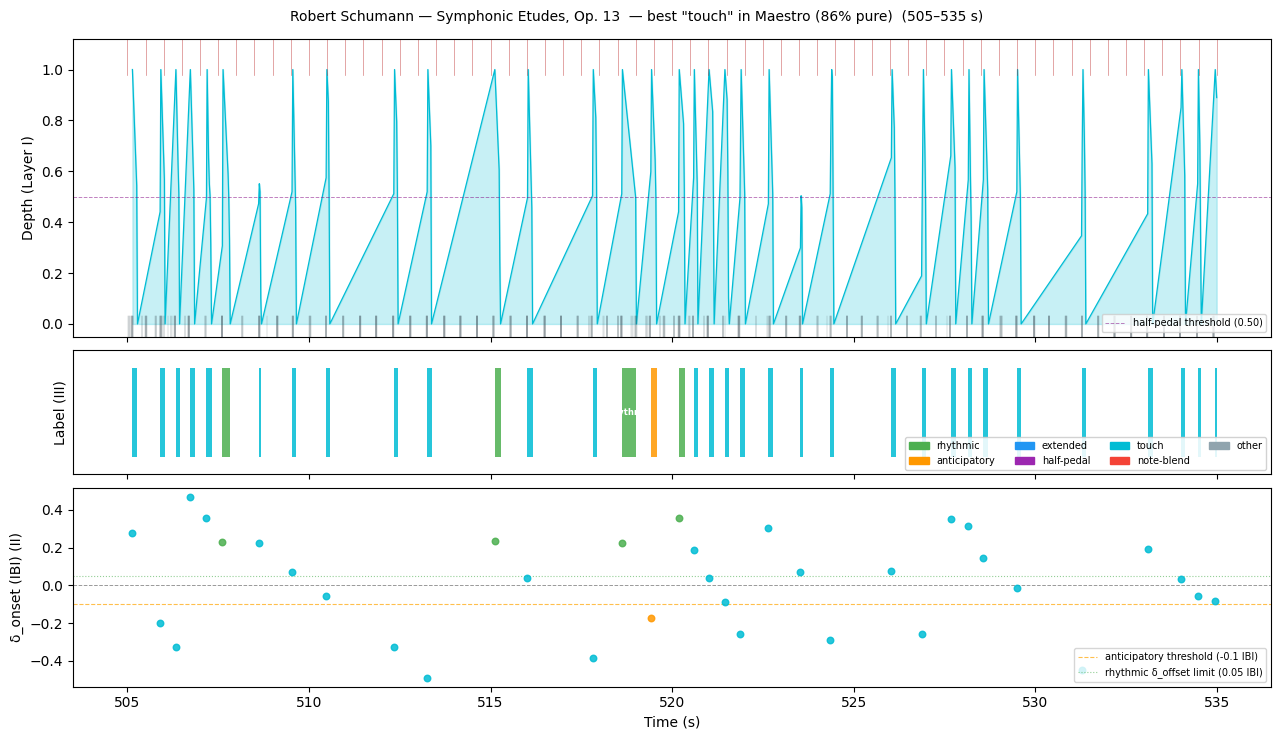

In [22]:
# Aligned view for the #1 pick of each of the 5 label types
LABEL_ORDER_5 = ['rhythmic', 'anticipatory', 'extended', 'half-pedal', 'touch']

for lbl in LABEL_ORDER_5:
    top = best[lbl][0]
    print(f'\nRendering best "{lbl}": {top["composer"]} — {top["title"]}  '
          f'({top["t_start"]}–{top["t_end"]}s, {top["purity_pct"]}% pure)')

    controls, note_ons, end_time, pm = load_midi_piece(top['midi_path'])
    raw = extract_pedal_events(controls, threshold=10)
    evs = [MaestroEvent(onset_sec=e.onset_sec, offset_sec=e.offset_sec,
                        times=e.times, depths=e.depths) for e in raw]
    layer2_maestro(evs, note_ons, pm)
    layer3_maestro(evs)
    t_raw = np.array([c['time']  for c in controls])
    v_raw = np.array([c['value'] for c in controls], dtype=float) / 127.0

    piece_info = dict(
        name=f'{top["composer"]} — {top["title"]}',
        short=top['composer'].split()[-1],
        midi=top['midi_path'],
        T0=top['t_start'], T1=top['t_end'],
        color=LABEL_COLORS[lbl],
    )
    r_tmp = dict(events=evs, t_raw=t_raw, v_raw=v_raw,
                 note_ons=note_ons, beats=pm.get_beats(),
                 end_time=end_time, piece=piece_info)
    plot_aligned_view(r_tmp, title_extra=f'  — best "{lbl}" in Maestro ({top["purity_pct"]:.0f}% pure)')

---
## Audio segments (requires Maestro WAV files)

Once the Maestro audio is downloaded to `/Volumes/Extreme SSD/maestro-v3.0.0`,
run once from the repo root:

```bash
python scripts/extract_audio_segments.py --top 5
# saves WAV clips to  segments/audio/<label>/
```

The cell below plays the top clip for each label type inline.
Any WAV that is not yet on disk is silently skipped.

In [23]:
import json, IPython.display as ipd

try:
    import soundfile as sf
    _SF_OK = True
except ImportError:
    _SF_OK = False
    print('soundfile not installed — skipping audio playback')

def _midi_to_wav(midi_path):
    return midi_path.replace('.midi', '.wav')

def _play_segment(wav_path, t_start, t_end, label, composer, title):
    """Load a slice of a WAV and display an audio player.  No-op if file missing."""
    if not _SF_OK:
        return
    from pathlib import Path
    if not Path(wav_path).exists():
        print(f'  [skip] {label}: {Path(wav_path).name} not on disk')
        return
    info = sf.info(wav_path)
    sr   = info.samplerate
    audio, _ = sf.read(wav_path,
                       start=int(t_start * sr),
                       stop=int(t_end   * sr),
                       always_2d=True)
    print(f'  [{label}]  {composer} — {title}  ({t_start:.0f}–{t_end:.0f}s)')
    ipd.display(ipd.Audio(audio.T, rate=sr))

with open('../scripts/best_segments.json') as f:
    _best = json.load(f)

for lbl in ['rhythmic', 'anticipatory', 'extended', 'half-pedal', 'touch']:
    top = _best[lbl][0]
    _play_segment(
        wav_path  = _midi_to_wav(top['midi_path']),
        t_start   = top['t_start'],
        t_end     = top['t_end'],
        label     = lbl,
        composer  = top['composer'],
        title     = top['title'],
    )

  [skip] rhythmic: MIDI-Unprocessed_04_R1_2008_01-04_ORIG_MID--AUDIO_04_R1_2008_wav--4.wav not on disk
  [skip] anticipatory: MIDI-Unprocessed_10_R1_2009_01-02_ORIG_MID--AUDIO_10_R1_2009_10_R1_2009_01_WAV.wav not on disk
  [skip] extended: MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_05_Track05_wav.wav not on disk
  [skip] half-pedal: MIDI-Unprocessed_XP_08_R1_2004_01-02_ORIG_MID--AUDIO_08_R1_2004_01_Track01_wav.wav not on disk
  [skip] touch: MIDI-UNPROCESSED_14-15_R1_2014_MID--AUDIO_15_R1_2014_wav--6.wav not on disk
